# SLV American Put Pricing Framework

**Contents:**
1. Core utilities (Black-Scholes, IV solver, kernel)
2. SLV engine (particle method, leverage, path simulation)
3. LSM pricing (polynomial & NN regression, Broadie-Andersen upper bound)
4. Heston calibration & Dupire local-vol surface
5. Diagnostic & plotting functions
6. Self-contained unit tests (toy model, S₀ = 100)

In [367]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import time, pathlib, pickle, hashlib, os, warnings

from scipy.stats import norm
from scipy.optimize import differential_evolution, minimize, least_squares, brentq
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter, gaussian_filter1d

import torch
import torch.nn as nn

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.25,
    'figure.facecolor': 'white',
})
warnings.filterwarnings('ignore')

## 1. Configuration

In [368]:
TICKERS       = ['NVDA']
START_DATE    = '2024-01-01'
END_DATE      = '2024-12-31'

# Option surface filters (for Heston calibration)
MONEYNESS_LO  = 0.80
MONEYNESS_HI  = 1.20
DTE_MIN_CALIB = 7
DTE_MAX_CALIB = 365

# DTE_MIN_CALIB = 30
# DTE_MAX_CALIB = 60

# American put pricing
T_PRICE        = 227/365
N_STEPS_PRICE  = 100
N_EXERCISE     = 12
N_BA_PATHS     = 200
N_NESTED       = 500

# Heston calibration
HESTON_RECALIB_DAYS = 5
HESTON_DE_MAXITER   = 120
HESTON_DE_POPSIZE   = 12
HESTON_NQUAD_CALIB  = 64

# SLV
SLV_N_CAL     = 50_000
SLV_KAPPA_BW  = 1.0

# NN hyper-parameters
NN_HIDDEN = (32, 32)
NN_EPOCHS = 50
NN_LR     = 3e-3
NN_WD     = 1e-4
NN_BATCH  = 8192

# Finite-difference bump
BUMP_PCT  = 0.005

# Cache
CACHE_DIR = pathlib.Path('cache')
CACHE_DIR.mkdir(exist_ok=True)

print(f"Study: {TICKERS}  |  {START_DATE} → {END_DATE}")
print(f"American put: T={T_PRICE}  |  {N_EXERCISE} exercise dates")

Study: ['NVDA']  |  2024-01-01 → 2024-12-31
American put: T=0.6219178082191781  |  12 exercise dates


## 2. Core Pricing Utilities

In [369]:
def bs_price(S, K, T, sigma, r=0.0, q=0.0, cp='call'):
    S, K, T, sigma = map(np.atleast_1d, [S, K, T, sigma])
    T = np.maximum(T, 1e-10)
    F  = S * np.exp((r - q) * T)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    w  = 1 if cp[0].lower() == 'c' else -1
    return np.squeeze(
        w * (F * norm.cdf(w * d1) - K * norm.cdf(w * d2)) * np.exp(-r * T))


def bs_vega(S, K, T, sigma, r=0.0, q=0.0):
    S, K, T, sigma = map(np.atleast_1d, [S, K, T, sigma])
    T = np.maximum(T, 1e-10)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return np.squeeze(S * np.exp(-q * T) * np.sqrt(T) * norm.pdf(d1))


def bs_impv_scalar(K, T, S, price, r=0.0, q=0.0, cp='call',
                   tol=1e-6, maxiter=500):
    if (K <= 0) or (T <= 0):
        return np.nan
    F = S * np.exp((r - q) * T)
    K_norm = K / F
    value = price * np.exp(r * T) / F
    opttype = 1 if cp[0].lower() == 'c' else -1
    value -= max(opttype * (1 - K_norm), 0)
    if value < 0:
        return np.nan
    if value == 0:
        return 0
    j = 1
    p = np.log(K_norm)
    if K_norm >= 1:
        x0 = np.sqrt(2 * p)
        x1 = x0 - (0.5 - K_norm * norm.cdf(-x0) - value) * np.sqrt(2 * np.pi)
        while (abs(x0 - x1) > tol * np.sqrt(T)) and (j < maxiter):
            x0 = x1
            d1 = -p / x1 + 0.5 * x1
            x1 = x1 - (norm.cdf(d1) - K_norm * norm.cdf(d1 - x1) - value) * np.sqrt(2 * np.pi) * np.exp(0.5 * d1**2)
            j += 1
    else:
        x0 = np.sqrt(-2 * p)
        x1 = x0 - (0.5 * K_norm - norm.cdf(-x0) - value) * np.sqrt(2 * np.pi) / K_norm
        while (abs(x0 - x1) > tol * np.sqrt(T)) and (j < maxiter):
            x0 = x1
            d1 = -p / x1 + 0.5 * x1
            x1 = x1 - (K_norm * norm.cdf(x1 - d1) - norm.cdf(-d1) - value) * np.sqrt(2 * np.pi) * np.exp(0.5 * d1**2)
            j += 1
    return x1 / np.sqrt(T)


bs_impv = np.vectorize(bs_impv_scalar, excluded={'cp', 'tol', 'maxiter'})


def quartic_kernel(x):
    x = np.clip(x, -1, 1)
    return (x + 1)**2 * (1 - x)**2


# quick check
_p = bs_price(100, 100, 1, 0.2, r=0.05, cp='call')
_iv = bs_impv_scalar(100, 1, 100, float(_p), r=0.05, cp='call')
assert abs(_iv - 0.2) < 1e-5, f"BS round-trip failed: {_iv}"
print("✓ BS pricing & implied-vol OK")

✓ BS pricing & implied-vol OK


## 3. Heston Model

In [370]:
def heston_cf(u, T, S, r, q, v0, kappa, theta, xi, rho, j=2):
    """Heston characteristic function (Albrecher 'Little Trap' form)."""
    u  = np.asarray(u, dtype=np.complex128)
    bj = (kappa - rho * xi) if j == 1 else kappa
    uj = 0.5 if j == 1 else -0.5
    a  = bj - rho * xi * 1j * u
    d  = np.sqrt(a**2 + xi**2 * (u**2 - 2 * uj * 1j * u))
    g  = (a - d) / (a + d)
    e  = np.exp(-d * T)
    D  = ((a - d) / xi**2) * (1 - e) / (1 - g * e)
    C  = (1j * u * (np.log(S) + (r - q) * T)
          + (kappa * theta / xi**2) * ((a - d) * T
          - 2 * np.log((1 - g * e) / (1 - g))))
    return np.exp(C + D * v0)


def heston_call(S, K_arr, T, r, q, v0, kappa, theta, xi, rho,
                n_quad=256):
    """European call prices for a vector of strikes."""
    K_arr = np.atleast_1d(np.asarray(K_arr, float))
    if T < 1e-10:
        return np.maximum(S * np.exp(-q * T) - K_arr, 0.0)
    nodes, weights = np.polynomial.legendre.leggauss(n_quad)
    umax = 250.0
    u = (nodes + 1) / 2 * umax
    w = weights * umax / 2
    cf1 = heston_cf(u, T, S, r, q, v0, kappa, theta, xi, rho, j=1)
    cf2 = heston_cf(u, T, S, r, q, v0, kappa, theta, xi, rho, j=2)
    logK   = np.log(K_arr)
    phase  = np.exp(-1j * u[None, :] * logK[:, None])
    inv_iu = 1.0 / (1j * u[None, :])
    P1 = 0.5 + np.dot(np.real(phase * cf1[None, :] * inv_iu), w) / np.pi
    P2 = 0.5 + np.dot(np.real(phase * cf2[None, :] * inv_iu), w) / np.pi
    return np.maximum(S * np.exp(-q * T) * P1 - K_arr * np.exp(-r * T) * P2, 0.0)


# sanity: Heston → BS when ξ → 0
_hc = float(heston_call(100, np.array([100.0]), 1.0, 0.05, 0.0,
                         0.04, 2.0, 0.04, 1e-6, -0.5)[0])
_bc = float(bs_price(100, 100, 1.0, 0.2, r=0.05))
assert abs(_hc - _bc) < 0.05, f"Heston ≠ BS when ξ→0: {_hc:.4f} vs {_bc:.4f}"
print("✓ Heston pricing OK")

✓ Heston pricing OK


## 4. WRDS / OptionMetrics Data Pipeline

| Table | Content |
|---|---|
| `optionm.opprcd` | daily option prices, greeks, IV |
| `optionm.secprd` | underlying daily close prices |
| `optionm.secnmd` | ticker → secid mapping |
| `optionm.zerocd` | zero-coupon rates |

In [371]:
try:
    import wrds
    _WRDS_AVAILABLE = True
except ImportError:
    _WRDS_AVAILABLE = False
    print("⚠ wrds package not installed – will look for cached parquets")


def _cache_path(name: str) -> pathlib.Path:
    return CACHE_DIR / f"{name}.parquet"


def _wrds_conn():
    if not hasattr(_wrds_conn, '_db'):
        _wrds_conn._db = wrds.Connection()
    return _wrds_conn._db


def get_secid(ticker: str) -> int:
    db = _wrds_conn()
    df = db.raw_sql(f"""
        SELECT secid FROM optionm.secnmd
        WHERE ticker = '{ticker}'
        ORDER BY effect_date DESC LIMIT 1
    """)
    return int(df['secid'].iloc[0])


def load_stock_prices(ticker: str, start: str, end: str) -> pd.DataFrame:
    fp = _cache_path(f"stock_{ticker}_{start}_{end}")
    if fp.exists():
        return pd.read_parquet(fp)
    secid = get_secid(ticker)
    db = _wrds_conn()
    df = db.raw_sql(f"""
        SELECT date, close
        FROM optionm.secprd
        WHERE secid = {secid}
          AND date BETWEEN '{start}' AND '{end}'
        ORDER BY date
    """)
    df['date'] = pd.to_datetime(df['date'])
    df.to_parquet(fp)
    print(f"  Cached stock data → {fp.name}")
    return df


def load_zero_curve(start: str, end: str) -> pd.DataFrame:
    fp = _cache_path(f"zero_{start}_{end}")
    if fp.exists():
        return pd.read_parquet(fp)
    db = _wrds_conn()
    df = db.raw_sql(f"""
        SELECT date, days, rate
        FROM optionm.zerocd
        WHERE date BETWEEN '{start}' AND '{end}'
        ORDER BY date, days
    """)
    df['date'] = pd.to_datetime(df['date'])
    df.to_parquet(fp)
    return df


def load_option_prices(ticker, start, end):
    fp = _cache_path(f"opts_{ticker}_{start}_{end}")
    if fp.exists():
        return pd.read_parquet(fp)
    db = _wrds_conn()
    secid_df = db.raw_sql(f"""
        SELECT DISTINCT secid FROM optionm.secnmd
        WHERE ticker = '{ticker}'
    """)
    if secid_df.empty:
        raise ValueError(f"Ticker '{ticker}' not found")
    secid = int(secid_df['secid'].iloc[0])
    print(f"  secid for {ticker}: {secid}")

    start_year = int(start[:4])
    end_year   = int(end[:4])
    parts = []
    for y in range(start_year, end_year + 1):
        parts.append(f"""
            SELECT date, exdate, cp_flag,
                   strike_price / 1000.0 AS strike,
                   best_bid, best_offer,
                   (best_bid + best_offer) / 2.0 AS mid,
                   impl_volatility AS iv,
                   delta, gamma, vega, theta,
                   volume, open_interest, contract_size
            FROM optionm.opprcd{y}
            WHERE secid = {secid}
              AND date BETWEEN '{start}' AND '{end}'
              AND best_bid > 0
              AND impl_volatility IS NOT NULL
              AND ss_flag = '0'
              AND exdate > date
        """)
    query = " UNION ALL ".join(parts) + "\n ORDER BY date, exdate, strike"
    df = db.raw_sql(query)
    df['date']   = pd.to_datetime(df['date'])
    df['exdate'] = pd.to_datetime(df['exdate'])
    df.to_parquet(fp)
    print(f"  Option prices: {len(df):,} rows  "
          f"({df['date'].min().date()} → {df['date'].max().date()})")
    return df


def get_risk_free_rate(zero_df, date, days_to_exp):
    sub = zero_df[zero_df['date'] == pd.Timestamp(date)]
    if sub.empty:
        return 0.04
    return float(np.interp(days_to_exp, sub['days'], sub['rate'] / 100.0))


def load_all_data(ticker):
    print(f"\n{'─'*60}")
    print(f"Loading data for {ticker}  ({START_DATE} → {END_DATE})")
    print(f"{'─'*60}")
    stock_df = load_stock_prices(ticker, START_DATE, END_DATE)
    opt_df   = load_option_prices(ticker, START_DATE, END_DATE)
    zero_df  = load_zero_curve(START_DATE, END_DATE)
    stock_df = stock_df.sort_values('date').reset_index(drop=True)
    stock_df['log_ret'] = np.log(stock_df['close'] / stock_df['close'].shift(1))
    opt_df = opt_df.merge(
        stock_df[['date', 'close']].rename(columns={'close': 'spot'}),
        on='date', how='left')
    opt_df['moneyness'] = opt_df['strike'] / opt_df['spot']
    opt_df['dte'] = (opt_df['exdate'] - opt_df['date']).dt.days
    print(f"  Stock rows : {len(stock_df):>8,}")
    print(f"  Option rows: {len(opt_df):>8,}")
    return stock_df, opt_df, zero_df


print("✓ Data pipeline ready"
      + (" (WRDS available)" if _WRDS_AVAILABLE else " (offline mode)"))

✓ Data pipeline ready (WRDS available)


## 5. Heston Calibration Pipeline

In [372]:
HESTON_BOUNDS = [
    (0.02, 1.5),      # v0
    (0.1,  20.0),     # kappa
    (0.02, 1.5),      # theta
    (0.1,  6.0),      # xi
    (-0.99, -0.10),   # rho
]
_LB = np.array([b[0] for b in HESTON_BOUNDS])
_UB = np.array([b[1] for b in HESTON_BOUNDS])


def _prepare_calib_groups(opt_df_date, S, r_fn, date):
    """Filter OTM options, compute call-equivalent prices & vega."""
    df = opt_df_date.copy()
    df = df[((df['cp_flag'] == 'C') & (df['strike'] >= S)) |
            ((df['cp_flag'] == 'P') & (df['strike'] <= S))].copy()
    df = df[(df['moneyness'] > MONEYNESS_LO) &
            (df['moneyness'] < MONEYNESS_HI)]
    df = df[(df['dte'] >= DTE_MIN_CALIB) & (df['dte'] <= DTE_MAX_CALIB)]
    if len(df) < 10:
        return None
    groups = []
    for exdate, grp in df.groupby('exdate'):
        T = (exdate - pd.Timestamp(date)).days / 365.0
        if T < 0.01:
            continue
        r = r_fn(date, int(T * 365))
        q = 0.0
        K = grp['strike'].values.astype(np.float64)
        mkt_mid = grp['mid'].values.astype(np.float64)
        cp = grp['cp_flag'].values
        call_p = np.where(
            cp == 'C', mkt_mid,
            mkt_mid + S * np.exp(-q * T) - K * np.exp(-r * T))
        call_p = np.maximum(call_p, 1e-6)
        iv = grp['iv'].values.astype(np.float64)
        vg = np.maximum(bs_vega(S, K, T, iv, r, q), 1e-4)
        groups.append((K, T, r, q, call_p, vg))
    return groups if groups else None


def _feller_penalty(kappa, theta, xi):
    return 5.0 * max(0.0, 0.8 - 2 * kappa * theta / (xi**2 + 1e-12))**2


def _heston_obj(params, groups, S):
    v0, kappa, theta, xi, rho = params
    penalty = _feller_penalty(kappa, theta, xi)
    sse, n = 0.0, 0
    for K, T, r, q, mkt, vg in groups:
        try:
            prices = heston_call(S, K, T, r, q,
                                 v0, kappa, theta, xi, rho,
                                 n_quad=HESTON_NQUAD_CALIB)
            sse += np.sum(((prices - mkt) / vg)**2)
            n += len(K)
        except Exception:
            return 1e6
    return sse / max(n, 1) + penalty


def _heston_residuals(params, groups, S):
    v0, kappa, theta, xi, rho = params
    parts = []
    for K, T, r, q, mkt, vg in groups:
        try:
            prices = heston_call(S, K, T, r, q,
                                 v0, kappa, theta, xi, rho,
                                 n_quad=HESTON_NQUAD_CALIB)
            parts.append((prices - mkt) / vg)
        except Exception:
            parts.append(np.full(len(K), 100.0))
    pen = np.sqrt(5.0) * max(0.0, 0.8 - 2 * kappa * theta / (xi**2 + 1e-12))
    parts.append(np.array([pen]))
    return np.concatenate(parts)


def calibrate_heston_on_date(opt_df_date, S, r_fn, date, prev_params=None):
    """Cold start: DE.  Warm start: least_squares + L-BFGS-B."""
    groups = _prepare_calib_groups(opt_df_date, S, r_fn, date)
    if groups is None:
        return prev_params
    if prev_params is not None:
        x0 = np.clip(prev_params, _LB + 1e-6, _UB - 1e-6)
        try:
            res = least_squares(
                _heston_residuals, x0, args=(groups, S),
                bounds=(_LB, _UB), method='trf', max_nfev=150,
                ftol=1e-10, xtol=1e-8, gtol=1e-8)
            best_x   = np.clip(res.x, _LB, _UB)
            best_obj = _heston_obj(best_x, groups, S)
        except Exception:
            best_x, best_obj = x0, 1e6
        try:
            res2 = minimize(
                _heston_obj, x0, args=(groups, S),
                method='L-BFGS-B', bounds=HESTON_BOUNDS,
                options={'maxiter': 200, 'ftol': 1e-10})
            if res2.fun < best_obj:
                best_x = np.clip(res2.x, _LB, _UB)
        except Exception:
            pass
        return best_x
    result = differential_evolution(
        _heston_obj, HESTON_BOUNDS, args=(groups, S),
        seed=42, maxiter=HESTON_DE_MAXITER,
        popsize=HESTON_DE_POPSIZE, tol=1e-8,
        mutation=(0.5, 1.5), recombination=0.9, polish=True)
    return result.x


def build_heston_param_series(stock_df, opt_df, zero_df):
    """Calibrate Heston at regular intervals. Returns dict date → params."""
    cache_key = hashlib.md5(
        f"{stock_df['date'].iloc[0]}_{stock_df['date'].iloc[-1]}_"
        f"{len(opt_df)}".encode()).hexdigest()[:10]
    cache_fp = CACHE_DIR / f"heston_{cache_key}.pkl"
    if cache_fp.exists():
        with open(cache_fp, 'rb') as f:
            hparams = pickle.load(f)
        print(f"  Loaded cached Heston params ({len(hparams)} dates)")
        return hparams

    dates = sorted(stock_df['date'].unique())
    r_fn  = lambda d, dte: get_risk_free_rate(zero_df, d, dte)
    hparams, prev = {}, None
    t0 = time.time()
    for i, d in enumerate(dates):
        if i % HESTON_RECALIB_DAYS != 0:
            continue
        S = float(stock_df.loc[stock_df['date'] == d, 'close'].iloc[0])
        odf = opt_df[opt_df['date'] == d]
        if odf.empty:
            continue
        params = calibrate_heston_on_date(odf, S, r_fn, d, prev)
        if params is not None:
            hparams[d] = params
            prev = params
        if len(hparams) % 10 == 0 and len(hparams) > 0:
            print(f"    {len(hparams)} dates calibrated  ({time.time()-t0:.0f}s)")

    print(f"  Heston calibrated on {len(hparams)} dates ({time.time()-t0:.0f}s)")
    with open(cache_fp, 'wb') as f:
        pickle.dump(hparams, f)
    return hparams


def lookup_heston_params(hparams, date):
    keys = sorted(hparams.keys())
    idx  = np.searchsorted(keys, pd.Timestamp(date), side='right') - 1
    return hparams[keys[max(0, idx)]]

## 6. Build Market Expiry Data from WRDS

Convert the WRDS option surface on a reference date into the
`expiries` format needed by the SLV calibration pipeline.

In [373]:
def build_expiries_from_wrds(opt_df, stock_df, zero_df, ref_date=None):
    """
    Extract expiries list from WRDS option data on a reference date.

    Returns
    -------
    S0       : float — spot price on ref_date
    expiries : list of dicts with keys T, R, IFwd, strikes, ivs
    """
    if ref_date is None:
        ref_date = opt_df['date'].max()
    ref_date = pd.Timestamp(ref_date)

    S0 = float(stock_df.loc[stock_df['date'] == ref_date, 'close'].iloc[0])
    df = opt_df[opt_df['date'] == ref_date].copy()
    df = df[(df['moneyness'] > MONEYNESS_LO) &
            (df['moneyness'] < MONEYNESS_HI)]
    df = df[(df['dte'] >= DTE_MIN_CALIB) & (df['dte'] <= DTE_MAX_CALIB)]

    expiries = []
    for exdate, grp in df.groupby('exdate'):
        T   = (exdate - ref_date).days / 365.0
        if T < 0.01:
            continue
        r   = get_risk_free_rate(zero_df, ref_date, int(T * 365))
        q   = 0.0

        # volume-weighted mid IV per strike
        strikes, ivs = [], []
        for K, sgrp in grp.groupby('strike'):
            iv_c = sgrp.loc[sgrp['cp_flag'] == 'C', 'iv']
            iv_p = sgrp.loc[sgrp['cp_flag'] == 'P', 'iv']
            vol_c = sgrp.loc[sgrp['cp_flag'] == 'C', 'volume'].sum()
            vol_p = sgrp.loc[sgrp['cp_flag'] == 'P', 'volume'].sum()
            iv_c_val = float(iv_c.iloc[0]) if len(iv_c) > 0 else np.nan
            iv_p_val = float(iv_p.iloc[0]) if len(iv_p) > 0 else np.nan
            if np.isnan(iv_c_val) and np.isnan(iv_p_val):
                continue
            if np.isnan(iv_c_val):
                iv_mid = iv_p_val
            elif np.isnan(iv_p_val):
                iv_mid = iv_c_val
            elif (vol_c + vol_p) > 0:
                iv_mid = (iv_c_val * vol_c + iv_p_val * vol_p) / (vol_c + vol_p)
            else:
                iv_mid = (iv_c_val + iv_p_val) / 2
            strikes.append(float(K))
            ivs.append(float(iv_mid))

        if len(strikes) < 3:
            continue

        F = S0 * np.exp((r - q) * T)
        expiries.append({
            'T': T, 'R': r, 'IFwd': F,
            'strikes': strikes, 'ivs': ivs,
        })

    expiries.sort(key=lambda e: e['T'])
    print(f"  Built {len(expiries)} expiry slices from WRDS data (S₀ = {S0:.2f})")
    for e in expiries:
        print(f"    T={e['T']:.4f} ({int(e['T']*365)}d)  "
              f"#strikes={len(e['strikes'])}  "
              f"IV range=[{min(e['ivs']):.3f}, {max(e['ivs']):.3f}]")
    return S0, expiries

## 7. Dupire Local-Vol Surface (from Heston)

In [374]:
def build_heston_local_vol(S0, heston_params, expiries,
                            n_K=400, n_T=250, n_quad=256):
    """
    Build Dupire σ_LV(K,T) from calibrated Heston.
    Returns (vol_fn, T_grid, K_grid, local_vol_surface).
    """
    v0, kappa_h, theta_h, xi_h, rho_h = heston_params

    T_mkt = np.array([e['T'] for e in expiries])
    r_mkt = np.array([e['R'] for e in expiries])
    F_mkt = np.array([e['IFwd'] for e in expiries])
    q_mkt = r_mkt - np.log(F_mkt / S0) / np.maximum(T_mkt, 1e-8)
    T_max = max(T_mkt) * 1.3

    T_grid = np.unique(np.concatenate([
        np.linspace(0.003, 0.02, 50),
        np.linspace(0.02,  0.10, 60),
        np.linspace(0.10,  T_max, 140),
    ]))
    n_T = len(T_grid)
    K_lo, K_hi = S0 * 0.30, S0 * 3.50
    K_grid = np.linspace(K_lo, K_hi, n_K)
    r_grid = np.interp(T_grid, T_mkt, r_mkt)
    q_grid = np.interp(T_grid, T_mkt, q_mkt)

    print(f"  Computing Heston call prices on {n_T}×{n_K} grid …")
    C = np.zeros((n_T, n_K))
    for i in range(n_T):
        C[i] = heston_call(S0, K_grid, T_grid[i], r_grid[i], q_grid[i],
                           v0, kappa_h, theta_h, xi_h, rho_h, n_quad=n_quad)

    dC_dT   = np.gradient(C,     T_grid, axis=0)
    dC_dK   = np.gradient(C,     K_grid, axis=1)
    d2C_dK2 = np.gradient(dC_dK, K_grid, axis=1)
    KK = K_grid[None, :]; rr = r_grid[:, None]; qq = q_grid[:, None]
    numer = 2.0 * (dC_dT + (rr - qq) * KK * dC_dK + qq * C)
    denom = KK**2 * d2C_dK2

    min_denom = 1e-8 * KK**2
    good = (denom > min_denom) & (numer > 0)
    local_var = np.full_like(numer, theta_h)
    local_var[good] = numer[good] / denom[good]
    local_var = np.clip(local_var, 0.02**2, 1.5**2)
    local_vol = np.sqrt(local_var)

    for i in range(n_T):
        sig = max(2.0, 6.0 * np.exp(-T_grid[i] / 0.03))
        local_vol[i] = gaussian_filter1d(local_vol[i], sigma=sig)
    local_vol = gaussian_filter1d(local_vol, sigma=1.5, axis=0)
    local_vol = np.clip(local_vol, 0.02, 1.5)

    pct_bad = 100 * (1 - good.mean())
    print(f"  Local vol ∈ [{local_vol.min():.4f}, {local_vol.max():.4f}]"
          f"   ({pct_bad:.1f}% fell back to θ)")

    lv_interp = RegularGridInterpolator(
        (T_grid, K_grid), local_vol,
        method='linear', bounds_error=False,
        fill_value=float(np.sqrt(theta_h)))

    def vol_fn(S, t):
        S_arr  = np.atleast_1d(np.asarray(S, dtype=float))
        t_clip = float(np.clip(t, T_grid[0], T_grid[-1]))
        S_clip = np.clip(S_arr, K_grid[0], K_grid[-1])
        pts    = np.stack([np.full(len(S_clip), t_clip), S_clip], axis=1)
        return np.clip(np.asarray(lv_interp(pts), dtype=float), 0.02, 1.5)

    return vol_fn, T_grid, K_grid, local_vol

## 7a. Dupire Local-Vol Surface (from Smoothed Market IVs)

In [375]:
from scipy.interpolate import CubicSpline

def build_market_local_vol(S0, expiries, n_K=400, iv_smooth_sigma=2.0,
                           plot_spline=True):
    """
    Build Dupire σ_LV(K,T) directly from market implied vols.

    Strategy
    --------
    1. Per-expiry: cubic-spline in log-moneyness, flat extrapolation.
    2. Across time: linear interpolation in total-variance w = σ²·T
       (ensures w is monotone ⇒ no calendar-spread arbitrage).
    3. Compute BS call prices on the (T, K) grid.
    4. Apply Dupire's formula via finite differences.
    5. Light Gaussian smoothing on the resulting local-vol surface.
    """

    T_mkt = np.array([e['T'] for e in expiries])
    r_mkt = np.array([e['R'] for e in expiries])
    F_mkt = np.array([e['IFwd'] for e in expiries])
    q_mkt = r_mkt - np.log(F_mkt / S0) / np.maximum(T_mkt, 1e-8)
    T_max = max(T_mkt) * 1.3

    # ── Grids ──────────────────────────────────────────────────
    T_grid = np.sort(np.unique(np.concatenate([
        T_mkt,
        np.linspace(max(T_mkt.min() * 0.5, 0.003), 0.02, 30),
        np.linspace(0.02, 0.10, 40),
        np.linspace(0.10, T_max, 80),
    ])))
    K_lo, K_hi = S0 * 0.50, S0 * 2.00
    K_grid = np.linspace(K_lo, K_hi, n_K)
    r_grid = np.interp(T_grid, T_mkt, r_mkt)
    q_grid = np.interp(T_grid, T_mkt, q_mkt)

    # ── Step 1: Interpolate market IV per expiry onto K_grid ──
    lm_grid = np.log(K_grid / S0)
    w_at_mkt_T = np.zeros((len(T_mkt), n_K))

    # storage for plotting
    spline_plot_data = []

    for i, exp in enumerate(expiries):
        Ks  = np.array(exp['strikes'])
        ivs = np.array(exp['ivs'])
        order = np.argsort(Ks)
        Ks, ivs = Ks[order], ivs[order]

        lm = np.log(Ks / S0)

        if len(Ks) >= 4:
            cs = CubicSpline(lm, ivs, bc_type='natural', extrapolate=True)
            iv_raw = cs(lm_grid)
        else:
            iv_raw = np.interp(lm_grid, lm, ivs)

        # flat extrapolation beyond observed range
        iv_raw[lm_grid < lm.min()] = ivs[0]
        iv_raw[lm_grid > lm.max()] = ivs[-1]

        # keep a copy before smoothing for the plot
        iv_before_smooth = iv_raw.copy()

        # optional per-slice smoothing
        if iv_smooth_sigma > 0:
            iv_interp = gaussian_filter1d(iv_raw, sigma=iv_smooth_sigma)
        else:
            iv_interp = iv_raw

        iv_interp = np.clip(iv_interp, 0.02, 2.0)
        w_at_mkt_T[i] = iv_interp**2 * T_mkt[i]

        spline_plot_data.append({
            'T': exp['T'],
            'dte': int(exp['T'] * 365),
            'K_mkt': Ks.copy(),
            'iv_mkt': ivs.copy(),
            'K_grid': K_grid.copy(),
            'iv_spline_raw': iv_before_smooth.copy(),
            'iv_spline_smooth': iv_interp.copy(),
        })

    # ── Plot the cubic-spline fits ─────────────────────────────
    if plot_spline:
        n_exp = len(spline_plot_data)
        n_cols = min(n_exp, 6)
        n_rows = int(np.ceil(n_exp / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(5 * n_cols, 4 * n_rows),
                                 squeeze=False)
        fig.suptitle('Cubic-Spline IV Fit per Expiry', fontsize=14, y=1.02)

        for idx, sd in enumerate(spline_plot_data):
            row, col = divmod(idx, n_cols)
            ax = axes[row, col]

            # market points
            ax.plot(sd['K_mkt'], sd['iv_mkt'], 'o',
                    c='#2176AE', ms=6, zorder=3, label='Market IV')

            # raw spline (before Gaussian smoothing)
            ax.plot(sd['K_grid'], sd['iv_spline_raw'],
                    '-', c='#AAAAAA', lw=1.2, alpha=0.7, label='Spline (raw)')

            # smoothed spline
            ax.plot(sd['K_grid'], sd['iv_spline_smooth'],
                    '-', c='#D7263D', lw=2, label='Spline (smoothed)')

            ax.axvline(S0, ls=':', c='grey', lw=0.8, label=f'S₀={S0:.0f}')

            # residual RMSE at market strikes
            iv_at_mkt = np.interp(sd['K_mkt'], sd['K_grid'], sd['iv_spline_smooth'])
            rmse = np.sqrt(np.mean((sd['iv_mkt'] - iv_at_mkt)**2))
            max_err = np.max(np.abs(sd['iv_mkt'] - iv_at_mkt))

            ax.set_title(f"T={sd['dte']}d  RMSE={rmse:.4f}  max|Δ|={max_err:.4f}",
                         fontsize=10)
            ax.set_xlabel('Strike')
            if col == 0:
                ax.set_ylabel('Implied Volatility')
            ax.legend(fontsize=7, loc='best')
            ax.grid(True, alpha=0.2)

        # hide unused axes
        for idx in range(n_exp, n_rows * n_cols):
            row, col = divmod(idx, n_cols)
            axes[row, col].set_visible(False)

        plt.tight_layout()
        plt.show()

    # ── Step 2: Interpolate total variance across time ─────────
    w_surface = np.zeros((len(T_grid), n_K))
    for j in range(n_K):
        w_surface[:, j] = np.interp(T_grid, T_mkt, w_at_mkt_T[:, j])

    # enforce monotonicity in T (no calendar arb)
    for j in range(n_K):
        w_surface[:, j] = np.maximum.accumulate(w_surface[:, j])

    IV_surface = np.sqrt(np.clip(
        w_surface / T_grid[:, None], 0.02**2, 2.0**2))

    # ── Step 3: BS call prices on the grid ─────────────────────
    C = np.zeros((len(T_grid), n_K))
    for i in range(len(T_grid)):
        C[i] = bs_price(S0, K_grid, T_grid[i], IV_surface[i],
                        r=r_grid[i], q=q_grid[i], cp='call')

    # ── Step 4: Dupire formula ─────────────────────────────────
    dC_dT   = np.gradient(C,     T_grid, axis=0)
    dC_dK   = np.gradient(C,     K_grid, axis=1)
    d2C_dK2 = np.gradient(dC_dK, K_grid, axis=1)

    KK = K_grid[None, :]
    rr = r_grid[:, None]
    qq = q_grid[:, None]
    numer = 2.0 * (dC_dT + (rr - qq) * KK * dC_dK + qq * C)
    denom = KK**2 * d2C_dK2

    min_denom = 1e-8 * KK**2
    good = (denom > min_denom) & (numer > 0)

    fallback = IV_surface**2
    local_var = np.where(good, numer / denom, fallback)
    local_var = np.clip(local_var, 0.02**2, 1.5**2)
    local_vol = np.sqrt(local_var)

    # ── Step 5: Smooth ─────────────────────────────────────────
    for i in range(len(T_grid)):
        sig = max(2.0, 5.0 * np.exp(-T_grid[i] / 0.03))
        local_vol[i] = gaussian_filter1d(local_vol[i], sigma=sig)
    local_vol = gaussian_filter1d(local_vol, sigma=1.0, axis=0)
    local_vol = np.clip(local_vol, 0.02, 1.5)

    pct_bad = 100 * (1 - good.mean())
    print(f"  Market local vol ∈ [{local_vol.min():.4f}, {local_vol.max():.4f}]"
          f"   ({pct_bad:.1f}% fell back to IV²)")

    # ── Interpolator ───────────────────────────────────────────
    lv_interp = RegularGridInterpolator(
        (T_grid, K_grid), local_vol,
        method='linear', bounds_error=False,
        fill_value=float(np.median(local_vol)))

    def vol_fn(S, t):
        S_arr  = np.atleast_1d(np.asarray(S, dtype=float))
        t_clip = float(np.clip(t, T_grid[0], T_grid[-1]))
        S_clip = np.clip(S_arr, K_grid[0], K_grid[-1])
        pts    = np.stack([np.full(len(S_clip), t_clip), S_clip], axis=1)
        return np.clip(np.asarray(lv_interp(pts), dtype=float), 0.02, 1.5)

    return vol_fn, T_grid, K_grid, local_vol

## 7b. Dupire Local-Vol Surface (from Quadratic Market IVs)

In [376]:
def build_market_local_vol_quad(S0, expiries, n_K=400, iv_smooth_sigma=1.0,
                           plot_fit=True):
    """
    Build Dupire σ_LV(K,T) directly from market implied vols.

    Strategy
    --------
    1. Per-expiry: quadratic fit in log-moneyness  σ(m) = a + b·m + c·m²
    2. Across time: linear interpolation in total-variance w = σ²·T
    3. Compute BS call prices on the (T, K) grid.
    4. Apply Dupire's formula via finite differences.
    5. Light Gaussian smoothing on the resulting local-vol surface.
    """

    T_mkt = np.array([e['T'] for e in expiries])
    r_mkt = np.array([e['R'] for e in expiries])
    F_mkt = np.array([e['IFwd'] for e in expiries])
    q_mkt = r_mkt - np.log(F_mkt / S0) / np.maximum(T_mkt, 1e-8)
    T_max = max(T_mkt) * 1.3

    # ── Grids ──────────────────────────────────────────────────
    T_grid = np.sort(np.unique(np.concatenate([
        T_mkt,
        np.linspace(max(T_mkt.min() * 0.5, 0.003), 0.02, 30),
        np.linspace(0.02, 0.10, 40),
        np.linspace(0.10, T_max, 80),
    ])))
    K_lo, K_hi = S0 * 0.80, S0 * 1.20
    K_grid = np.linspace(K_lo, K_hi, n_K)
    r_grid = np.interp(T_grid, T_mkt, r_mkt)
    q_grid = np.interp(T_grid, T_mkt, q_mkt)

    # ── Step 1: Quadratic fit per expiry in log-moneyness ─────
    lm_grid = np.log(K_grid / S0)
    w_at_mkt_T = np.zeros((len(T_mkt), n_K))

    fit_plot_data = []

    for i, exp in enumerate(expiries):
        Ks  = np.array(exp['strikes'])
        ivs = np.array(exp['ivs'])
        order = np.argsort(Ks)
        Ks, ivs = Ks[order], ivs[order]

        lm = np.log(Ks / S0)

        # ── Quadratic:  σ(m) = a + b·m + c·m² ───────────────
        coeffs = np.polyfit(lm, ivs, deg=2)        # [c, b, a]
        iv_raw = np.polyval(coeffs, lm_grid)

        iv_raw = np.clip(iv_raw, 0.02, 2.0)

        # optional light smoothing (usually unnecessary for quadratic)
        if iv_smooth_sigma > 0:
            iv_smooth = gaussian_filter1d(iv_raw, sigma=iv_smooth_sigma)
        else:
            iv_smooth = iv_raw

        iv_smooth = np.clip(iv_smooth, 0.02, 2.0)
        w_at_mkt_T[i] = iv_smooth**2 * T_mkt[i]

        # fitted values at market strikes (for RMSE)
        iv_fitted_at_mkt = np.polyval(coeffs, lm)

        fit_plot_data.append({
            'T': exp['T'],
            'dte': int(exp['T'] * 365),
            'K_mkt': Ks.copy(),
            'lm_mkt': lm.copy(),
            'iv_mkt': ivs.copy(),
            'iv_fitted_mkt': iv_fitted_at_mkt.copy(),
            'K_grid': K_grid.copy(),
            'iv_quad_raw': iv_raw.copy(),
            'iv_quad_smooth': iv_smooth.copy(),
            'coeffs': coeffs.copy(),
        })

    # ── Plot the quadratic fits ────────────────────────────────
    if plot_fit:
        n_exp = len(fit_plot_data)
        n_cols = min(n_exp, 6)
        n_rows = int(np.ceil(n_exp / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(5 * n_cols, 4 * n_rows),
                                 squeeze=False)
        fig.suptitle('Quadratic IV Fit per Expiry   '
                     r'$\sigma(m) = a + b\,m + c\,m^2$',
                     fontsize=14, y=1.02)

        for idx, sd in enumerate(fit_plot_data):
            row, col = divmod(idx, n_cols)
            ax = axes[row, col]

            # market points
            ax.plot(sd['K_mkt'], sd['iv_mkt'], 'o',
                    c='#2176AE', ms=6, zorder=3, label='Market IV')

            # quadratic fit (before any smoothing)
            ax.plot(sd['K_grid'], sd['iv_quad_raw'],
                    '-', c='#AAAAAA', lw=1.2, alpha=0.7, label='Quad (raw)')

            # after smoothing
            ax.plot(sd['K_grid'], sd['iv_quad_smooth'],
                    '-', c='#D7263D', lw=2, label='Quad (smooth)')

            ax.axvline(S0, ls=':', c='grey', lw=0.8, label=f'S₀={S0:.0f}')

            # stats at market strikes
            rmse = np.sqrt(np.mean((sd['iv_mkt'] - sd['iv_fitted_mkt'])**2))
            max_err = np.max(np.abs(sd['iv_mkt'] - sd['iv_fitted_mkt']))
            c_, b_, a_ = sd['coeffs']
            ax.set_title(f"T={sd['dte']}d  RMSE={rmse:.4f}  "
                         f"max|Δ|={max_err:.4f}\n"
                         f"a={a_:.3f}  b={b_:.3f}  c={c_:.3f}",
                         fontsize=9)
            ax.set_xlabel('Strike')
            if col == 0:
                ax.set_ylabel('Implied Volatility')
            ax.legend(fontsize=7, loc='best')
            ax.grid(True, alpha=0.2)

        for idx in range(n_exp, n_rows * n_cols):
            row, col = divmod(idx, n_cols)
            axes[row, col].set_visible(False)

        plt.tight_layout()
        plt.show()

    # ── Step 2: Interpolate total variance across time ─────────
    w_surface = np.zeros((len(T_grid), n_K))
    for j in range(n_K):
        w_surface[:, j] = np.interp(T_grid, T_mkt, w_at_mkt_T[:, j])

    for j in range(n_K):
        w_surface[:, j] = np.maximum.accumulate(w_surface[:, j])

    IV_surface = np.sqrt(np.clip(
        w_surface / T_grid[:, None], 0.02**2, 2.0**2))

    # ── Step 3: BS call prices on the grid ─────────────────────
    C = np.zeros((len(T_grid), n_K))
    for i in range(len(T_grid)):
        C[i] = bs_price(S0, K_grid, T_grid[i], IV_surface[i],
                        r=r_grid[i], q=q_grid[i], cp='call')

    # ── Step 4: Dupire formula ─────────────────────────────────
    dC_dT   = np.gradient(C,     T_grid, axis=0)
    dC_dK   = np.gradient(C,     K_grid, axis=1)
    d2C_dK2 = np.gradient(dC_dK, K_grid, axis=1)

    KK = K_grid[None, :]
    rr = r_grid[:, None]
    qq = q_grid[:, None]
    numer = 2.0 * (dC_dT + (rr - qq) * KK * dC_dK + qq * C)
    denom = KK**2 * d2C_dK2

    min_denom = 1e-8 * KK**2
    good = (denom > min_denom) & (numer > 0)

    fallback = IV_surface**2
    local_var = np.where(good, numer / denom, fallback)
    local_var = np.clip(local_var, 0.02**2, 1.5**2)
    local_vol = np.sqrt(local_var)

    # ── Step 5: Smooth ─────────────────────────────────────────
    for i in range(len(T_grid)):
        sig = max(2.0, 5.0 * np.exp(-T_grid[i] / 0.03))
        local_vol[i] = gaussian_filter1d(local_vol[i], sigma=sig)
    local_vol = gaussian_filter1d(local_vol, sigma=1.0, axis=0)
    local_vol = np.clip(local_vol, 0.02, 1.5)

    pct_bad = 100 * (1 - good.mean())
    print(f"  Market local vol ∈ [{local_vol.min():.4f}, {local_vol.max():.4f}]"
          f"   ({pct_bad:.1f}% fell back to IV²)")

    # ── Interpolator ───────────────────────────────────────────
    lv_interp = RegularGridInterpolator(
        (T_grid, K_grid), local_vol,
        method='linear', bounds_error=False,
        fill_value=float(np.median(local_vol)))

    def vol_fn(S, t):
        S_arr  = np.atleast_1d(np.asarray(S, dtype=float))
        t_clip = float(np.clip(t, T_grid[0], T_grid[-1]))
        S_clip = np.clip(S_arr, K_grid[0], K_grid[-1])
        pts    = np.stack([np.full(len(S_clip), t_clip), S_clip], axis=1)
        return np.clip(np.asarray(lv_interp(pts), dtype=float), 0.02, 1.5)

    return vol_fn, T_grid, K_grid, local_vol

## 8. SLV Engine

In [377]:
'''def compute_leverage_on_grid(S_particles, Y_particles, S_grid_k,
                              t_k, sigma0, vol_fn, S0, kappa_bw, N_cal):
    with np.errstate(invalid='ignore', divide='ignore'):
        sigma_grid = vol_fn(S_grid_k, t_k) if callable(vol_fn) else np.full(len(S_grid_k), vol_fn)
        sigma_ref  = float(np.atleast_1d(vol_fn(S0, t_k))[0]) if callable(vol_fn) else float(vol_fn)
        h = kappa_bw * sigma_ref * S0 * np.sqrt(max(t_k, 0.15)) * N_cal**(-0.2)
        u = (S_particles[None, :] - S_grid_k[:, None]) / h
        K_vals = quartic_kernel(u)
        stoch_var = sigma0**2 * np.exp(2 * Y_particles)
        numer = K_vals @ stoch_var
        denom = K_vals.sum(axis=1)
        cond_exp = np.where(denom > 0, numer / denom, sigma0**2)
        lev_grid = np.sqrt(np.clip(sigma_grid**2 / cond_exp, 1e-4, 1e2))
    return lev_grid
'''
'''def compute_leverage_on_grid(S_particles, Y_particles, S_grid_k,
                              t_k, sigma0, vol_fn, S0, kappa_bw, N_cal):
    with np.errstate(invalid='ignore', divide='ignore'):
        sigma_grid = (vol_fn(S_grid_k, t_k) if callable(vol_fn)
                      else np.full(len(S_grid_k), vol_fn))
        sigma_ref  = (float(np.atleast_1d(vol_fn(S0, t_k))[0])
                      if callable(vol_fn) else float(vol_fn))

        # ── FIXED: remove the floor, use actual t_k with a small guard ──
        t_eff = max(t_k, 1e-3)
        h = kappa_bw * sigma_ref * S0 * np.sqrt(t_eff) * N_cal**(-0.2)
        # ensure h is at least the particle spacing
        h = max(h, 2.0 * np.std(S_particles) * N_cal**(-0.3))

        u = (S_particles[None, :] - S_grid_k[:, None]) / h
        K_vals = quartic_kernel(u)
        stoch_var = sigma0**2 * np.exp(2 * Y_particles)
        numer = K_vals @ stoch_var
        denom = K_vals.sum(axis=1)

        # ── FIXED: more robust fallback ──
        min_count = max(10, 0.001 * N_cal)
        reliable = denom > min_count
        cond_exp = np.where(reliable, numer / denom,
                            np.mean(stoch_var))     # global mean fallback
        lev_grid = np.sqrt(np.clip(sigma_grid**2 / cond_exp, 0.05, 5.0))
    return lev_grid'''

def compute_leverage_on_grid(S_particles, Y_particles, S_grid_k,
                              t_k, T_total,
                              sigma0, vol_fn, S0, kappa_bw, N_cal,
                              L_floor=0.3, L_cap=3.0):
    with np.errstate(invalid='ignore', divide='ignore'):
        sigma_grid = (vol_fn(S_grid_k, t_k) if callable(vol_fn)
                      else np.full(len(S_grid_k), vol_fn))
        sigma_ref  = (float(np.atleast_1d(vol_fn(S0, t_k))[0])
                      if callable(vol_fn) else float(vol_fn))

        # ── adaptive bandwidth ──
        # (a) within-sim: wider at early steps
        time_frac = t_k / T_total if T_total > 0 else 1.0
        intra_scale = np.clip(3.0 * (1.0 - time_frac), 1.0, 3.0)

        # (b) absolute-T: wider when the WHOLE sim is short
        T_days = T_total * 365
        if T_days < 30:
            abs_scale = 3.0
        elif T_days < 60:
            abs_scale = 2.0
        elif T_days < 120:
            abs_scale = 1.5
        else:
            abs_scale = 1.0

        bw_scale = max(intra_scale, abs_scale)   # take the more conservative

        t_eff = max(t_k, 1e-3)
        h = bw_scale * kappa_bw * sigma_ref * S0 * np.sqrt(t_eff) * N_cal**(-0.2)
        h = max(h, 2.0 * np.std(S_particles) * N_cal**(-0.3))

        u = (S_particles[None, :] - S_grid_k[:, None]) / h
        K_vals = quartic_kernel(u)
        stoch_var = sigma0**2 * np.exp(2 * Y_particles)
        numer = K_vals @ stoch_var
        denom = K_vals.sum(axis=1)

        min_count = max(10, 0.001 * N_cal)
        reliable = denom > min_count
        cond_exp = np.where(reliable, numer / denom,
                            np.mean(stoch_var))

        lev_grid = np.sqrt(np.clip(sigma_grid**2 / cond_exp, 1e-4, 1e2))

        # ── clamp leverage ──
        lev_grid = np.clip(lev_grid, L_floor, L_cap)

    return lev_grid

'''def particle_method(S0, sigma0, Y0, rho, gamma, kappa_mr, T,
                    n_steps, N_cal, vol_fn, kappa_bw,
                    r=0.0, q=0.0,                          # ← NEW
                    n_grid=200, seed=42):
    dt_sim  = T / n_steps
    exp_kdt = np.exp(-kappa_mr * dt_sim)
    std_Y   = gamma * np.sqrt((1 - np.exp(-2 * kappa_mr * dt_sim)) / (2 * kappa_mr))
    rho_bar = rho * np.sqrt(2 * (1 - exp_kdt) / (kappa_mr * dt_sim * (1 + exp_kdt)))
    rng     = np.random.default_rng(seed)
    logS    = np.full(N_cal, np.log(S0))
    Y       = np.full(N_cal, float(Y0))
    lev_store = []
    for k in range(n_steps):
        t_k = k * dt_sim
        S_particles = np.exp(logS)
        Y_old = Y.copy()
        S_lo, S_hi = S_particles.min(), S_particles.max()
        margin   = 0.05 * (S_hi - S_lo + 1e-8)
        S_grid_k = np.linspace(S_lo - margin, S_hi + margin, n_grid)
        lev_grid = compute_leverage_on_grid(
            S_particles, Y_old, S_grid_k, t_k, sigma0, vol_fn, S0, kappa_bw, N_cal)
        lev_store.append((S_grid_k.copy(), lev_grid.copy()))
        lev_p = np.interp(S_particles, S_grid_k, lev_grid)
        Z1 = rng.standard_normal(N_cal); Z2 = rng.standard_normal(N_cal)
        Y    = exp_kdt * Y_old + std_Y * Z2
        veff = sigma0 * np.exp(Y_old) * lev_p
        logS = (logS + (r - q - 0.5 * veff**2) * dt_sim       # ← FIXED
                + veff * np.sqrt(dt_sim) * (np.sqrt(1 - rho_bar**2) * Z1 + rho_bar * Z2))
    return lev_store, logS, Y'''

def particle_method(S0, sigma0, Y0, rho, gamma, kappa_mr, T,
                    n_steps, N_cal, vol_fn, kappa_bw,
                    r=0.0, q=0.0,
                    n_grid=200, seed=42):
    dt_sim  = T / n_steps
    exp_kdt = np.exp(-kappa_mr * dt_sim)
    std_Y   = gamma * np.sqrt((1 - np.exp(-2 * kappa_mr * dt_sim)) / (2 * kappa_mr))
    rho_bar = rho * np.sqrt(2 * (1 - exp_kdt) / (kappa_mr * dt_sim * (1 + exp_kdt)))
    rng     = np.random.default_rng(seed)
    logS    = np.full(N_cal, np.log(S0))
    Y       = np.full(N_cal, float(Y0))
    lev_store = []
    for k in range(n_steps):
        t_k = k * dt_sim
        S_particles = np.exp(logS)
        Y_old = Y.copy()
        S_lo, S_hi = S_particles.min(), S_particles.max()
        margin   = 0.05 * (S_hi - S_lo + 1e-8)
        S_grid_k = np.linspace(S_lo - margin, S_hi + margin, n_grid)
        lev_grid = compute_leverage_on_grid(
            S_particles, Y_old, S_grid_k,
            t_k, T,                                    # ← PASS T
            sigma0, vol_fn, S0, kappa_bw, N_cal)
        lev_store.append((S_grid_k.copy(), lev_grid.copy()))
        lev_p = np.interp(S_particles, S_grid_k, lev_grid)
        Z1 = rng.standard_normal(N_cal); Z2 = rng.standard_normal(N_cal)
        Y    = exp_kdt * Y_old + std_Y * Z2
        veff = sigma0 * np.exp(Y_old) * lev_p
        logS = (logS + (r - q - 0.5 * veff**2) * dt_sim
                + veff * np.sqrt(dt_sim) * (np.sqrt(1 - rho_bar**2) * Z1 + rho_bar * Z2))
    return lev_store, logS, Y

def slv_paths_matrix(S0, sigma0, Y0, rho, gamma, kappa_mr, T,
                     n_steps, N, lev_store, exercise_indices,
                     r=0.0, q=0.0,                          # ← NEW
                     seed=0):
    dt_sim  = T / n_steps
    exp_kdt = np.exp(-kappa_mr * dt_sim)
    std_Y   = gamma * np.sqrt((1 - np.exp(-2 * kappa_mr * dt_sim)) / (2 * kappa_mr))
    rho_bar = rho * np.sqrt(2 * (1 - exp_kdt) / (kappa_mr * dt_sim * (1 + exp_kdt)))
    rng     = np.random.default_rng(seed)
    logS    = np.full(N, np.log(S0))
    Y       = np.full(N, float(Y0))
    ex_set  = set(exercise_indices[1:])
    paths      = np.empty((len(exercise_indices), N))
    paths[0]   = S0
    Y_paths    = np.empty((len(exercise_indices), N))
    Y_paths[0] = Y0
    ex_idx = 1
    for k in range(n_steps):
        S_grid_k, lev_grid_k = lev_store[k]
        S_now = np.exp(logS)
        Y_old = Y.copy()
        lev   = np.interp(S_now, S_grid_k, lev_grid_k)
        Z1 = rng.standard_normal(N); Z2 = rng.standard_normal(N)
        Y    = exp_kdt * Y_old + std_Y * Z2
        veff = sigma0 * np.exp(Y_old) * lev
        logS = (logS + (r - q - 0.5 * veff**2) * dt_sim       # ← FIXED
                + veff * np.sqrt(dt_sim) * (np.sqrt(1 - rho_bar**2) * Z1 + rho_bar * Z2))
        if (k + 1) in ex_set:
            paths[ex_idx]   = np.exp(logS)
            Y_paths[ex_idx] = Y
            ex_idx += 1
    return paths, Y_paths

## 9. SLV Parameter Estimation from Price History

In [378]:
def estimate_slv_params(stock_df, window=20):
    """Estimate SLV stochastic-vol parameters from daily closes."""
    df = stock_df.copy()
    df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
    df['rvol']    = df['log_ret'].rolling(window).std() * np.sqrt(252)
    df            = df.dropna(subset=['rvol'])

    sigma0   = float(df['rvol'].iloc[-1])
    long_vol = float(df['rvol'].mean())
    Y0       = float(np.log(sigma0 / long_vol))

    df['d_rvol'] = df['rvol'].diff()
    v = df.dropna(subset=['log_ret', 'd_rvol'])
    rho = float(v['log_ret'].corr(v['d_rvol']))

    df['log_rvol'] = np.log(df['rvol'])
    gamma = float(df['log_rvol'].diff().dropna().std() * np.sqrt(252))

    y = df['log_rvol'].values[1:]
    x = df['log_rvol'].values[:-1]
    mask = np.isfinite(x) & np.isfinite(y)
    b = np.polyfit(x[mask], y[mask], 1)[0]
    kappa = float(-252 * np.log(np.clip(b, 1e-6, 0.9999)))

    params = dict(sigma0=sigma0, Y0=Y0, rho=rho, gamma=gamma,
                  kappa=kappa, kappa_bw=SLV_KAPPA_BW, N_cal=SLV_N_CAL)
    print(f"  Estimated SLV params:")
    for k, val in params.items():
        print(f"    {k:>10s} = {val:.4f}" if isinstance(val, float) else f"    {k:>10s} = {val}")
    return params

'''def estimate_slv_params(stock_df, expiries, S0):
    """
    Estimate SLV stochastic-vol parameters anchored to the IMPLIED surface,
    not historical realized vol.
    """
    # ── sigma0: ATM implied vol from shortest expiry ──────────
    atm_ivs, atm_Ts = [], []
    for exp in expiries:
        Ks  = np.array(exp['strikes'])
        ivs = np.array(exp['ivs'])
        # interpolate IV at S0
        order = np.argsort(Ks)
        Ks, ivs = Ks[order], ivs[order]
        atm_iv = float(np.interp(S0, Ks, ivs))
        atm_ivs.append(atm_iv)
        atm_Ts.append(exp['T'])
    atm_ivs = np.array(atm_ivs)
    atm_Ts  = np.array(atm_Ts)

    sigma0 = float(atm_ivs[0])          # anchor to short-end ATM IV
    Y0     = 0.0                          # start at long-run mean

    # ── rho: from skew of shortest expiry ─────────────────────
    exp0 = expiries[0]
    Ks   = np.array(exp0['strikes'])
    ivs  = np.array(exp0['ivs'])
    order = np.argsort(Ks)
    Ks, ivs = Ks[order], ivs[order]
    lm   = np.log(Ks / S0)
    # skew ≈ dσ/d(log K) near ATM
    atm_mask = np.abs(lm) < 0.10
    if atm_mask.sum() >= 3:
        skew = float(np.polyfit(lm[atm_mask], ivs[atm_mask], 1)[0])
    else:
        skew = float(np.polyfit(lm, ivs, 1)[0])
    # rough mapping: skew ≈ ρ·ξ / (2σ√T) → ρ ≈ skew * 2σ√T / ξ
    # use a simple empirical mapping
    rho = float(np.clip(skew / sigma0, -0.95, -0.05))
    if rho > -0.05:
        rho = -0.50   # default for equities

    # ── gamma (vol-of-vol): from IV term structure ────────────
    if len(atm_ivs) >= 3:
        # vol-of-vol relates to how fast the smile flattens with T
        # rough: γ ≈ std of ATM IV changes across T, annualized
        d_iv = np.diff(atm_ivs)
        d_T  = np.diff(atm_Ts)
        gamma = float(np.clip(np.std(d_iv / np.sqrt(d_T)), 0.1, 2.0))
    else:
        gamma = 0.5

    # ── kappa (mean reversion): from term structure slope ─────
    if len(atm_ivs) >= 3 and atm_ivs[-1] != atm_ivs[0]:
        # faster convergence of term structure → higher kappa
        # fit: σ_ATM(T) ≈ σ_∞ + (σ_0 - σ_∞)·e^{-κT/2}
        from scipy.optimize import curve_fit
        def _ts_model(T, sigma_inf, kap):
            return sigma_inf + (atm_ivs[0] - sigma_inf) * np.exp(-kap * T / 2)
        try:
            popt, _ = curve_fit(_ts_model, atm_Ts, atm_ivs,
                                p0=[atm_ivs[-1], 2.0],
                                bounds=([0.01, 0.1], [1.0, 20.0]))
            kappa = float(popt[1])
        except Exception:
            kappa = 2.0
    else:
        kappa = 2.0

    params = dict(
        sigma0=sigma0, Y0=Y0, rho=rho, gamma=gamma,
        kappa=kappa, kappa_bw=SLV_KAPPA_BW, N_cal=SLV_N_CAL,
    )
    print(f"  Estimated SLV params (implied-anchored):")
    for k, val in params.items():
        print(f"    {k:>10s} = {val:.4f}" if isinstance(val, float)
              else f"    {k:>10s} = {val}")
    return params'''
    
# def estimate_slv_params(stock_df, expiries, S0):
#     """SLV params anchored to the IMPLIED surface, not historical rvol."""

#     # sigma0 = ATM IV from shortest expiry
#     atm_ivs = []
#     for exp in expiries:
#         Ks  = np.array(exp['strikes'])
#         ivs = np.array(exp['ivs'])
#         order = np.argsort(Ks)
#         atm_iv = float(np.interp(S0, Ks[order], ivs[order]))
#         atm_ivs.append(atm_iv)
#     atm_ivs = np.array(atm_ivs)
#     atm_Ts  = np.array([e['T'] for e in expiries])

#     sigma0 = float(atm_ivs[0])
#     Y0     = 0.0

#     # rho from short-end skew
#     exp0 = expiries[0]
#     Ks   = np.array(exp0['strikes'])
#     ivs  = np.array(exp0['ivs'])
#     order = np.argsort(Ks)
#     Ks, ivs = Ks[order], ivs[order]
#     lm = np.log(Ks / S0)
#     atm_mask = np.abs(lm) < 0.10
#     if atm_mask.sum() >= 3:
#         skew = float(np.polyfit(lm[atm_mask], ivs[atm_mask], 1)[0])
#     else:
#         skew = float(np.polyfit(lm, ivs, 1)[0])
#     rho = float(np.clip(skew / sigma0, -0.95, -0.10))

#     # gamma from IV term structure variation
#     if len(atm_ivs) >= 3:
#         d_iv = np.diff(atm_ivs)
#         d_T  = np.diff(atm_Ts)
#         gamma = float(np.clip(np.std(d_iv / np.sqrt(d_T)), 0.1, 2.0))
#     else:
#         gamma = 0.5

#     # kappa from term structure convergence speed
#     if len(atm_ivs) >= 3:
#         from scipy.optimize import curve_fit
#         def _ts(T, s_inf, kap):
#             return s_inf + (atm_ivs[0] - s_inf) * np.exp(-kap * T / 2)
#         try:
#             popt, _ = curve_fit(_ts, atm_Ts, atm_ivs,
#                                 p0=[atm_ivs[-1], 2.0],
#                                 bounds=([0.01, 0.1], [1.0, 20.0]))
#             kappa = float(popt[1])
#         except Exception:
#             kappa = 2.0
#     else:
#         kappa = 2.0

#     params = dict(sigma0=sigma0, Y0=Y0, rho=rho, gamma=gamma,
#                   kappa=kappa, kappa_bw=SLV_KAPPA_BW, N_cal=SLV_N_CAL)
#     print(f"  Estimated SLV params (implied-anchored):")
#     for k, val in params.items():
#         print(f"    {k:>10s} = {val:.4f}" if isinstance(val, float)
#               else f"    {k:>10s} = {val}")
#     return params

'def estimate_slv_params(stock_df, expiries, S0):\n    """\n    Estimate SLV stochastic-vol parameters anchored to the IMPLIED surface,\n    not historical realized vol.\n    """\n    # ── sigma0: ATM implied vol from shortest expiry ──────────\n    atm_ivs, atm_Ts = [], []\n    for exp in expiries:\n        Ks  = np.array(exp[\'strikes\'])\n        ivs = np.array(exp[\'ivs\'])\n        # interpolate IV at S0\n        order = np.argsort(Ks)\n        Ks, ivs = Ks[order], ivs[order]\n        atm_iv = float(np.interp(S0, Ks, ivs))\n        atm_ivs.append(atm_iv)\n        atm_Ts.append(exp[\'T\'])\n    atm_ivs = np.array(atm_ivs)\n    atm_Ts  = np.array(atm_Ts)\n\n    sigma0 = float(atm_ivs[0])          # anchor to short-end ATM IV\n    Y0     = 0.0                          # start at long-run mean\n\n    # ── rho: from skew of shortest expiry ─────────────────────\n    exp0 = expiries[0]\n    Ks   = np.array(exp0[\'strikes\'])\n    ivs  = np.array(exp0[\'ivs\'])\n    order = np.argsort(Ks

## 10. LSM Pricing & Broadie–Andersen Upper Bound

In [379]:
# ── Polynomial regression ─────────────────────────────────────

def regression_polynomial(X, Y, S_current, degree=3, **kwargs):
    coeffs = np.polyfit(X, Y, deg=degree)
    return np.polyval(coeffs, S_current), {'type': 'polynomial', 'coeffs': coeffs, 'degree': degree}


# ── Neural-network regression ─────────────────────────────────

class ContinuationValueNet(nn.Module):
    def __init__(self, input_dim=1, hidden=(64, 64)):
        super().__init__()
        layers = []
        d = input_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU()]
            d = h
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def _nn_predict(model_info, S):
    m = model_info
    m['model'].eval()
    with torch.no_grad():
        Sn = torch.tensor((S - m['X_mean']) / m['X_std'],
                          dtype=torch.float32, device=m['device']).unsqueeze(-1)
        return m['model'](Sn).cpu().numpy() * m['Y_std'] + m['Y_mean']


def regression_neural_network(X, Y, S_current,
                               hidden=(64, 64), epochs=200, lr=1e-3,
                               batch_size=2048, weight_decay=1e-4, **kwargs):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    xm, xs = float(np.mean(X)), float(np.std(X)) + 1e-8
    ym, ys = float(np.mean(Y)), float(np.std(Y)) + 1e-8
    Xt = torch.tensor((X - xm) / xs, dtype=torch.float32, device=device).unsqueeze(-1)
    Yt = torch.tensor((Y - ym) / ys, dtype=torch.float32, device=device)
    net = ContinuationValueNet(1, hidden).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    ds = torch.utils.data.TensorDataset(Xt, Yt)
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)
    net.train()
    for _ in range(epochs):
        for xb, yb in dl:
            loss = nn.functional.mse_loss(net(xb), yb)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 5.0)
            opt.step()
        sch.step()
    net.eval()
    info = {'type': 'neural_network', 'model': net,
            'X_mean': xm, 'X_std': xs, 'Y_mean': ym, 'Y_std': ys,
            'device': device}
    return _nn_predict(info, S_current), info


# ── Exercise-or-continue ──────────────────────────────────────

def exer_or_cont(i, S, models, K, r, ts):
    S = np.atleast_1d(S)
    if i >= len(ts) - 1:
        return np.maximum(K - S, 0) > 0
    if i < 1 or i - 1 >= len(models):
        return np.zeros(len(S), dtype=bool)
    m  = models[i - 1]
    ev = np.maximum(K - S, 0)
    if m['type'] == 'polynomial':
        cv = np.polyval(m['coeffs'], S)
    elif m['type'] == 'neural_network':
        cv = _nn_predict(m, S)
    else:
        raise ValueError(f"Unknown model type {m['type']}")
    return ev > cv


# ── LSM pricer (basic) ────────────────────────────────────────

def ls_pricer(paths, K, r, ts, regression_func, **regression_params):
    n_steps, n_paths = paths.shape
    payoff = np.maximum(K - paths[-1], 0)
    exercise_policy = {'models': [], 'ts': ts, 'K': K, 'r': r}
    for i in range(n_steps - 2, 0, -1):
        discount          = np.exp(-r * (ts[i + 1] - ts[i]))
        payoff_discounted = payoff * discount
        exercise_value    = np.maximum(K - paths[i], 0)
        tau = ts[-1] - ts[i]
        cont_value, model = regression_func(
            paths[i], payoff_discounted, paths[i],
            K=K, r=r, tau=tau, **regression_params)
        exercise_policy['models'].insert(0, model)
        mask         = exercise_value > cont_value
        pf_new       = payoff_discounted.copy()
        pf_new[mask] = exercise_value[mask]
        payoff       = pf_new
    price = np.mean(payoff * np.exp(-r * (ts[1] - ts[0])))
    return price, exercise_policy


# ── LSM pricer with diagnostics ───────────────────────────────

def ls_pricer_diag(paths, K, r, ts, reg_func, **reg_kw):
    n_ex, n_paths = paths.shape
    payoff = np.maximum(K - paths[-1], 0)
    models, diags = [], []
    for i in range(n_ex - 2, 0, -1):
        disc = np.exp(-r * (ts[i + 1] - ts[i]))
        pf_d = payoff * disc
        ex_v = np.maximum(K - paths[i], 0)
        tau  = ts[-1] - ts[i]
        c_hat, mod = reg_func(paths[i], pf_d, paths[i], K=K, r=r, tau=tau, **reg_kw)
        models.insert(0, mod)
        res = pf_d - c_hat
        mse = float(np.mean(res**2))
        ss_r = float(np.sum(res**2))
        ss_t = float(np.sum((pf_d - pf_d.mean())**2))
        r2  = 1.0 - ss_r / (ss_t + 1e-15)
        diags.insert(0, {'idx': i, 't': ts[i], 'mse': mse, 'r2': r2})
        mask         = ex_v > c_hat
        pf_new       = pf_d.copy()
        pf_new[mask] = ex_v[mask]
        payoff       = pf_new
    price = float(np.mean(payoff * np.exp(-r * (ts[1] - ts[0]))))
    return price, {'models': models, 'ts': ts, 'K': K, 'r': r}, diags


# ── LSM pricer with scatter data ──────────────────────────────

def ls_pricer_with_scatter(paths, K, r, ts_ex, reg_fn, **reg_kw):
    N, M = paths.shape
    n_ex = M - 1
    H       = np.maximum(K - paths, 0.0)
    cf_val  = H[:, -1].copy()
    cf_tidx = np.full(N, n_ex, dtype=int)
    models  = [None] * (n_ex + 1)
    diags, scatter_data = [], []

    for j in range(n_ex - 1, 0, -1):
        itm   = H[:, j] > 0
        n_itm = itm.sum()
        if n_itm < 20:
            continue
        dt_cf  = ts_ex[cf_tidx[itm]] - ts_ex[j]
        Y_true = cf_val[itm] * np.exp(-r * dt_cf)
        S_j = paths[itm, j]
        X   = S_j.reshape(-1, 1)
        model = reg_fn(X, Y_true, **reg_kw)
        Y_hat = model.predict(X).ravel()
        models[j] = model

        ss_res = np.sum((Y_true - Y_hat)**2)
        ss_tot = np.sum((Y_true - Y_true.mean())**2)
        mse    = ss_res / n_itm
        r2     = 1.0 - ss_res / max(ss_tot, 1e-12)
        diags.append({'idx': j, 't': ts_ex[j], 'mse': mse, 'r2': r2})

        S_lo, S_hi = np.percentile(S_j, [0.5, 99.5])
        S_grid = np.linspace(S_lo, S_hi, 600)
        Y_curve = model.predict(S_grid.reshape(-1, 1)).ravel()
        scatter_data.append({
            'j': j, 't': ts_ex[j], 'S': S_j.copy(),
            'Y_true': Y_true.copy(), 'Y_hat': Y_hat.copy(),
            'intrinsic': H[itm, j].copy(),
            'S_grid': S_grid, 'Y_curve': Y_curve,
            'mse': mse, 'r2': r2, 'n_itm': n_itm,
        })
        exercise  = H[itm, j] >= Y_hat
        ex_global = np.where(itm)[0][exercise]
        cf_val[ex_global]  = H[ex_global, j]
        cf_tidx[ex_global] = j

    price = np.mean(cf_val * np.exp(-r * ts_ex[cf_tidx]))
    diags.reverse(); scatter_data.reverse()
    return price, {'models': models}, diags, scatter_data


# ── Nested Monte Carlo ────────────────────────────────────────

def nested_mc(S, Y_start, lev_store, exercise_indices,
              sigma0, rho, gamma, kappa_mr,
              r, q, i, ts, nnested, models, K, dt_fine, seed=None):
    nested_S = np.full(nnested, float(S))
    nested_Y = np.full(nnested, float(Y_start))
    tot_payoff = 0.0
    exp_kdt = np.exp(-kappa_mr * dt_fine)
    std_Y   = gamma * np.sqrt((1 - np.exp(-2 * kappa_mr * dt_fine)) / (2 * kappa_mr))
    rho_bar = rho * np.sqrt(2 * (1 - exp_kdt) / (kappa_mr * dt_fine * (1 + exp_kdt)))
    rng = np.random.default_rng(seed)
    for j in range(i + 1, len(ts)):
        step_start = exercise_indices[j - 1]
        step_end   = exercise_indices[j]
        for step_k in range(step_start, step_end):
            S_grid, lev_grid = lev_store[step_k]
            lev    = np.interp(nested_S, S_grid, lev_grid)
            Z1 = rng.standard_normal(len(nested_S))
            Z2 = rng.standard_normal(len(nested_S))
            Y_old  = nested_Y.copy()
            nested_Y = exp_kdt * Y_old + std_Y * Z2
            veff   = sigma0 * np.exp(Y_old) * lev
            nested_S = nested_S * np.exp(
                (r - q) * dt_fine - 0.5 * veff**2 * dt_fine
                + veff * np.sqrt(dt_fine) * (np.sqrt(1 - rho_bar**2) * Z1 + rho_bar * Z2))
        exer_vals = np.maximum(K - nested_S, 0)
        if j < len(ts) - 1:
            ind = exer_or_cont(j, nested_S, models, K, r, ts)
            tot_payoff += np.sum(exer_vals[ind]) * np.exp(-r * ts[j])
            nested_S = nested_S[~ind]; nested_Y = nested_Y[~ind]
            if len(nested_S) == 0:
                break
        else:
            tot_payoff += np.sum(exer_vals) * np.exp(-r * ts[j])
    return tot_payoff / nnested


# ── BA upper bound ────────────────────────────────────────────

def compute_ba_upper(price_lsm, models, paths_ba, Y_ba,
                     lev_store_p, exercise_idx_p,
                     sigma0, rho, gamma, kappa_mr,
                     r_price, ts_ex, N_nested, K_put, dt_p):
    exer_fn = lambda S: np.maximum(K_put - S, 0)
    V  = np.full(paths_ba.shape, np.nan)
    EV = np.full(paths_ba.shape, np.nan)
    V[0] = EV[0] = price_lsm
    for i in range(1, len(ts_ex) - 1):
        ev  = exer_fn(paths_ba[i])
        ind = exer_or_cont(i, paths_ba[i], models, K_put, r_price, ts_ex)
        for j in np.nonzero(ind)[0]:
            V[i, j]  = ev[j] * np.exp(-r_price * ts_ex[i])
            EV[i, j] = nested_mc(
                paths_ba[i, j], Y_ba[i, j], lev_store_p, exercise_idx_p,
                sigma0, rho, gamma, kappa_mr,
                r_price, 0.0, i, ts_ex, N_nested, models, K_put, dt_p)
        for j in np.nonzero(~ind)[0]:
            val = nested_mc(
                paths_ba[i, j], Y_ba[i, j], lev_store_p, exercise_idx_p,
                sigma0, rho, gamma, kappa_mr,
                r_price, 0.0, i, ts_ex, N_nested, models, K_put, dt_p)
            V[i, j] = val; EV[i, j] = val
    V[-1]      = exer_fn(paths_ba[-1]) * np.exp(-r_price * ts_ex[-1])
    hedges     = np.zeros(paths_ba.shape)
    hedges[1:] = np.cumsum(V[1:] - EV[:-1], axis=0)
    return float(np.mean(np.amax(
        exer_fn(paths_ba[1:]) * np.exp(-r_price * ts_ex[1:, None]) - hedges[1:], axis=0)))

 ## 11. Diagnostic Plots

In [380]:
def plot_calibration_fit(expiries, S0, heston_params, n_quad=256):
    v0, kappa, theta, xi, rho = heston_params
    n_exp = len(expiries)
    fig, axes = plt.subplots(1, min(n_exp, 6), figsize=(5*min(n_exp, 6), 4), squeeze=False)
    fig.suptitle('Heston Fit to Market', fontsize=14, y=1.03)
    for i, exp in enumerate(expiries[:6]):
        ax = axes[0, i]
        T = exp['T']; r = exp['R']; F = exp['IFwd']
        q = r - np.log(F / S0) / T if T > 1e-8 else 0.0
        K_arr = np.array(exp['strikes']); iv_mkt = np.array(exp['ivs'])
        K_dense = np.linspace(K_arr.min()*0.95, K_arr.max()*1.05, 200)
        prices_dense = heston_call(S0, K_dense, T, r, q, v0, kappa, theta, xi, rho, n_quad=n_quad)
        iv_mod = np.array([bs_impv_scalar(K, T, S0, float(p), r=r, q=q, cp='call')
                           for K, p in zip(K_dense, prices_dense)])
        ax.plot(K_arr, iv_mkt, 'o-', c='#2176AE', ms=5, lw=1.5, label='Market IV')
        ax.plot(K_dense, iv_mod, '--', c='#D7263D', lw=2, label='Heston IV')
        ax.axvline(S0, ls=':', c='grey', lw=0.7)
        rmse = np.sqrt(np.mean((iv_mkt - np.interp(K_arr, K_dense, iv_mod))**2))
        ax.set_title(f"T = {int(T*365)}d  RMSE={rmse:.4f}", fontsize=11)
        ax.set_xlabel('Strike')
        if i == 0: ax.set_ylabel('Implied Vol')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
    plt.tight_layout(); plt.show()


def plot_local_vol_surface(T_grid, K_grid, lv_surface, S0, expiries=None):
    fig, ax = plt.subplots(figsize=(9, 5))
    TT, KK = np.meshgrid(T_grid, K_grid, indexing='ij')
    lvls = np.linspace(lv_surface.min(), min(lv_surface.max(), 1.0), 30)
    cs = ax.contourf(TT, KK, lv_surface, levels=lvls, cmap='viridis')
    plt.colorbar(cs, ax=ax, label='Local Vol')
    ax.axhline(S0, color='w', ls='--', lw=1, label=f'S₀ = {S0}')
    if expiries:
        for exp in expiries:
            for K in exp['strikes']:
                ax.plot(exp['T'], K, 'rx', ms=6)
    ax.set_xlabel('T'); ax.set_ylabel('Strike')
    ax.set_title('Dupire Local Volatility')
    ax.legend(loc='upper right'); plt.tight_layout(); plt.show()


'''def plot_slv_smile_check(expiries, S0, slv_p, vol_fn):
    n_exp = len(expiries)
    fig, axes = plt.subplots(1, n_exp, figsize=(5*n_exp, 4), squeeze=False)
    fig.suptitle('SLV Smile Calibration', fontsize=14, y=1.03)
    for i, exp in enumerate(expiries):
        T_cal = exp['T']
        n_steps_cal = max(100, int(100 * T_cal))
        _, logS_cal, _ = particle_method(
            S0, slv_p['sigma0'], slv_p['Y0'], slv_p['rho'],
            slv_p['gamma'], slv_p['kappa'],
            T_cal, n_steps_cal, slv_p['N_cal'], vol_fn, slv_p['kappa_bw'])
        S_T = np.exp(logS_cal)
        K_list = np.array(exp['strikes']); iv_mkt = np.array(exp['ivs'])
        F_mc = S_T.mean()
        call_mc = np.array([np.maximum(S_T - K_, 0).mean() for K_ in K_list])
        put_mc  = np.array([np.maximum(K_ - S_T, 0).mean() for K_ in K_list])
        iv_model = np.array([
            bs_impv_scalar(K_, T_cal, S0, float(p), r=0.0, q=0.0,
                           cp=('put' if K_ < F_mc else 'call'))
            for K_, p in zip(K_list, np.where(K_list < F_mc, put_mc, call_mc))])
        max_err = np.nanmax(np.abs(iv_model - iv_mkt))
        print(f"  T={int(T_cal*365)}d  max|ΔIV|={max_err:.4f}  {'✓' if max_err < 0.01 else '!'}")
        ax = axes[0, i]
        ax.plot(K_list, iv_mkt,   'o-',  c='#2176AE', ms=5, lw=1.5, label='Market IV')
        ax.plot(K_list, iv_model, 's--', c='#D7263D', ms=5, lw=1.5, label='SLV Model IV')
        ax.axvline(S0, ls=':', c='grey', lw=0.7)
        rmse = np.sqrt(np.nanmean((iv_model - iv_mkt)**2))
        ax.set_title(f"T={int(T_cal*365)}d  RMSE={rmse:.4f}", fontsize=11)
        ax.set_xlabel('Strike')
        if i == 0: ax.set_ylabel('Implied Volatility')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
    plt.tight_layout(); plt.show()'''
    
def plot_slv_smile_check(expiries, S0, slv_p, vol_fn, tol=0.01):
    n_exp = len(expiries)
    fig, axes = plt.subplots(1, n_exp, figsize=(5*n_exp, 4), squeeze=False)
    fig.suptitle('SLV Smile Calibration', fontsize=14, y=1.03)

    for i, exp in enumerate(expiries):
        T_cal  = exp['T']
        T_days = int(T_cal * 365)
        F      = exp['IFwd']
        R      = exp.get('R', 0.0)
        Q      = R - np.log(F / S0) / max(T_cal, 1e-8)

        # ── adaptive moneyness filter ──────────────────────────
        if T_days < 60:
            max_mono = 0.05
        elif T_days < 120:
            max_mono = 0.10
        else:
            max_mono = 1.0

        K_all   = np.array(exp['strikes'])
        iv_all  = np.array(exp['ivs'])
        moneyness = np.abs(K_all / F - 1.0)
        mask = moneyness <= max_mono

        # ── more particles for short T ─────────────────────────
        if T_days < 60:
            N_cal_use = max(slv_p['N_cal'] * 4, 200_000)
        elif T_days < 120:
            N_cal_use = max(slv_p['N_cal'] * 2, 100_000)
        else:
            N_cal_use = slv_p['N_cal']

        # ── MC sim with proper r, q ────────────────────────────
        n_steps_cal = max(100, int(100 * T_cal))
        _, logS_cal, _ = particle_method(
            S0, slv_p['sigma0'], slv_p['Y0'], slv_p['rho'],
            slv_p['gamma'], slv_p['kappa'],
            T_cal, n_steps_cal, N_cal_use, vol_fn, slv_p['kappa_bw'],
            r=R, q=Q)
        S_T  = np.exp(logS_cal)
        F_mc = S_T.mean()

        # ── model IV for ALL strikes (for plotting) ────────────
        call_mc = np.array([np.maximum(S_T - K_, 0).mean() for K_ in K_all])
        put_mc  = np.array([np.maximum(K_ - S_T, 0).mean() for K_ in K_all])
        iv_model = np.array([
            bs_impv_scalar(K_, T_cal, S0, float(p), r=R, q=Q,
                           cp=('put' if K_ < F_mc else 'call'))
            for K_, p in zip(K_all, np.where(K_all < F_mc, put_mc, call_mc))])

        # ── errors only on FILTERED strikes ────────────────────
        iv_err  = np.abs(iv_model[mask] - iv_all[mask])
        max_err = np.nanmax(iv_err) if mask.any() else np.nan
        rmse    = np.sqrt(np.nanmean(iv_err**2)) if mask.any() else np.nan
        ok      = '✓' if max_err < tol else '!'

        print(f"  T={T_days}d  max|ΔIV|={max_err:.4f}  RMSE={rmse:.4f}  "
              f"[{mask.sum()}/{len(K_all)} strikes, ±{max_mono*100:.0f}% mono, "
              f"N={N_cal_use//1000}k]  {ok}")

        # ── plot ───────────────────────────────────────────────
        ax = axes[0, i]
        out = ~mask
        if out.any():
            ax.plot(K_all[out], iv_all[out],   'o', c='#2176AE', ms=4, alpha=0.25)
            ax.plot(K_all[out], iv_model[out], 's', c='#D7263D', ms=4, alpha=0.25)

        ax.plot(K_all[mask], iv_all[mask],   'o-',  c='#2176AE', ms=5, lw=1.5, label='Market IV')
        ax.plot(K_all[mask], iv_model[mask], 's--', c='#D7263D', ms=5, lw=1.5, label='SLV Model IV')

        ax.axvline(S0, ls=':', c='grey', lw=0.7)
        ax.axvline(F * (1 + max_mono), ls='--', c='green', lw=0.5, alpha=0.5)
        ax.axvline(F * (1 - max_mono), ls='--', c='green', lw=0.5, alpha=0.5,
                   label=f'±{max_mono*100:.0f}% mono')

        ax.set_title(f"T={T_days}d  RMSE={rmse:.4f}  {ok}", fontsize=11)
        ax.set_xlabel('Strike')
        if i == 0:
            ax.set_ylabel('Implied Volatility')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

'''def plot_slv_smile_check(expiries, S0, slv_p, vol_fn, tol=0.01):
    n_exp = len(expiries)
    fig, axes = plt.subplots(1, n_exp, figsize=(5*n_exp, 4), squeeze=False)
    fig.suptitle('SLV Smile Calibration', fontsize=14, y=1.03)

    for i, exp in enumerate(expiries):
        T_cal  = exp['T']
        T_days = int(T_cal * 365)
        F      = exp['IFwd']
        R      = exp.get('R', 0.0)
        Q      = R - np.log(F / S0) / max(T_cal, 1e-8)

        # ── adaptive moneyness filter ──────────────────────────
        if T_days < 60:
            max_mono = 0.05
        elif T_days < 120:
            max_mono = 0.10
        else:
            max_mono = 1.0

        K_all   = np.array(exp['strikes'])
        iv_all  = np.array(exp['ivs'])
        moneyness = np.abs(K_all / F - 1.0)
        mask = moneyness <= max_mono

        # ── MC sim ─────────────────────────────────────────────
        n_steps_cal = max(100, int(100 * T_cal))
        _, logS_cal, _ = particle_method(
            S0, slv_p['sigma0'], slv_p['Y0'], slv_p['rho'],
            slv_p['gamma'], slv_p['kappa'],
            T_cal, n_steps_cal, slv_p['N_cal'], vol_fn, slv_p['kappa_bw'],
            r=R, q=Q)
        S_T  = np.exp(logS_cal)
        F_mc = S_T.mean()

        # ── compute model IV for ALL strikes (for plotting) ───
        call_mc = np.array([np.maximum(S_T - K_, 0).mean() for K_ in K_all])
        put_mc  = np.array([np.maximum(K_ - S_T, 0).mean() for K_ in K_all])
        iv_model = np.array([
            bs_impv_scalar(K_, T_cal, S0, float(p), r=R, q=Q,
                           cp=('put' if K_ < F_mc else 'call'))
            for K_, p in zip(K_all, np.where(K_all < F_mc, put_mc, call_mc))])

        # ── errors only on FILTERED strikes ────────────────────
        iv_err   = np.abs(iv_model[mask] - iv_all[mask])
        max_err  = np.nanmax(iv_err) if mask.any() else np.nan
        rmse     = np.sqrt(np.nanmean(iv_err**2)) if mask.any() else np.nan
        ok       = '✓' if max_err < tol else '!'

        print(f"  T={T_days}d  max|ΔIV|={max_err:.4f}  RMSE={rmse:.4f}  "
              f"[{mask.sum()}/{len(K_all)} strikes, ±{max_mono*100:.0f}% mono]  {ok}")

        # ── plot ───────────────────────────────────────────────
        ax = axes[0, i]

        # dim the out-of-band strikes
        out = ~mask
        if out.any():
            ax.plot(K_all[out], iv_all[out],   'o', c='#2176AE', ms=4, alpha=0.25)
            ax.plot(K_all[out], iv_model[out], 's', c='#D7263D', ms=4, alpha=0.25)

        # solid for in-band strikes
        ax.plot(K_all[mask], iv_all[mask],   'o-',  c='#2176AE', ms=5, lw=1.5, label='Market IV')
        ax.plot(K_all[mask], iv_model[mask], 's--', c='#D7263D', ms=5, lw=1.5, label='SLV Model IV')

        ax.axvline(S0, ls=':', c='grey', lw=0.7)
        ax.axvline(F * (1 + max_mono), ls='--', c='green', lw=0.5, alpha=0.5)
        ax.axvline(F * (1 - max_mono), ls='--', c='green', lw=0.5, alpha=0.5,
                   label=f'±{max_mono*100:.0f}% mono')

        ax.set_title(f"T={T_days}d  RMSE={rmse:.4f}  {ok}", fontsize=11)
        ax.set_xlabel('Strike')
        if i == 0:
            ax.set_ylabel('Implied Volatility')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()'''

def plot_regression_overlay(scatter_poly, scatter_nn, K, n_cols=6, max_pts=4000, seed=42):
    n_steps = min(len(scatter_poly), len(scatter_nn))
    idx = np.round(np.linspace(0, n_steps - 1, n_cols)).astype(int)
    fig, axes = plt.subplots(1, n_cols, figsize=(4.2*n_cols, 4.5), squeeze=False, sharey=True)
    fig.suptitle(f'Poly-3 vs NN  (K = {K})', fontsize=14, y=1.03)
    rng = np.random.default_rng(seed)
    for col, si in enumerate(idx):
        ax = axes[0, col]; dp = scatter_poly[si]; dn = scatter_nn[si]
        S, Y = dp['S'], dp['Y_true']; n = len(S)
        if n > max_pts:
            pick = rng.choice(n, max_pts, replace=False); S, Y = S[pick], Y[pick]
        ax.scatter(S, Y, s=1.5, alpha=0.1, c='#aaaaaa', rasterized=True)
        ax.plot(dp['S_grid'], dp['Y_curve'], c='#2176AE', lw=2.5, label=f"Poly-3 (R²={dp['r2']:.3f})")
        ax.plot(dn['S_grid'], dn['Y_curve'], c='#D7263D', lw=2.5, ls='--', label=f"NN (R²={dn['r2']:.3f})")
        ax.plot(dp['S_grid'], np.maximum(K - dp['S_grid'], 0), 'k:', lw=1.2, alpha=0.5, label='Intrinsic')
        ax.axvline(K, ls=':', c='grey', lw=0.6)
        ax.set_title(f"t = {dp['t']:.4f}", fontsize=10); ax.set_xlabel('S')
        if col == 0: ax.set_ylabel('Continuation Value')
        if col == n_cols - 1: ax.legend(fontsize=7, loc='best')
    plt.tight_layout(); plt.show()


def plot_exercise_boundary(scatter_poly, scatter_nn, K):
    def find_boundary(d, K):
        S_g, C_g = d['S_grid'], d['Y_curve']
        h_g = np.maximum(K - S_g, 0)
        crossings = np.where(np.diff(np.sign(C_g - h_g)))[0]
        if len(crossings) == 0: return np.nan
        candidates = S_g[crossings]; candidates = candidates[candidates < K]
        return candidates[-1] if len(candidates) > 0 else np.nan
    ts_p, bs_p, ts_n, bs_n = [], [], [], []
    for d in scatter_poly:
        b = find_boundary(d, K)
        if not np.isnan(b): ts_p.append(d['t']); bs_p.append(b)
    for d in scatter_nn:
        b = find_boundary(d, K)
        if not np.isnan(b): ts_n.append(d['t']); bs_n.append(b)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(ts_p, bs_p, 'o-', c='#2176AE', lw=2, ms=4, label='Poly-3')
    ax.plot(ts_n, bs_n, 's--', c='#D7263D', lw=2, ms=4, label='NN')
    ax.axhline(K, ls=':', c='grey', label=f'K = {K}')
    ax.set_xlabel('Time t'); ax.set_ylabel('S*(t)')
    ax.set_title(f'Early-Exercise Boundary  (K = {K})')
    ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


def plot_r2_mse_over_time(scatter_poly, scatter_nn, K):
    ts_p = [d['t'] for d in scatter_poly]; ts_n = [d['t'] for d in scatter_nn]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Regression Quality Over Time  (K = {K})', fontsize=14)
    ax1.plot(ts_p, [d['r2'] for d in scatter_poly], 'o-', c='#2176AE', lw=2, ms=5, label='Poly-3')
    ax1.plot(ts_n, [d['r2'] for d in scatter_nn],   's--', c='#D7263D', lw=2, ms=5, label='NN')
    ax1.set_xlabel('t'); ax1.set_ylabel('R²'); ax1.set_ylim(0, 1.05); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(ts_p, [d['mse'] for d in scatter_poly], 'o-', c='#2176AE', lw=2, ms=5, label='Poly-3')
    ax2.plot(ts_n, [d['mse'] for d in scatter_nn],   's--', c='#D7263D', lw=2, ms=5, label='NN')
    ax2.set_xlabel('t'); ax2.set_ylabel('MSE'); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_residual_analysis(scatter_poly, scatter_nn, K, n_cols=6):
    n_steps = min(len(scatter_poly), len(scatter_nn))
    idx = np.round(np.linspace(0, n_steps - 1, n_cols)).astype(int)
    fig, axes = plt.subplots(2, n_cols, figsize=(4.2*n_cols, 7), squeeze=False)
    fig.suptitle(f'Residual Analysis  (K = {K})', fontsize=14, y=1.02)
    for col, si in enumerate(idx):
        dp = scatter_poly[si]; dn = scatter_nn[si]
        res_p = dp['Y_true'] - dp['Y_hat']; res_n = dn['Y_true'] - dn['Y_hat']
        ax = axes[0, col]
        ax.scatter(dp['S'], res_p, s=1, alpha=0.1, c='#2176AE', rasterized=True, label='Poly-3')
        ax.scatter(dn['S'], res_n, s=1, alpha=0.1, c='#D7263D', rasterized=True, label='NN')
        ax.axhline(0, c='k', lw=0.8)
        ax.set_title(f"t = {dp['t']:.4f}", fontsize=10)
        if col == 0: ax.set_ylabel('Residual')
        if col == n_cols - 1: ax.legend(fontsize=7, markerscale=6)
        ax = axes[1, col]
        clip = np.percentile(np.abs(np.concatenate([res_p, res_n])), 99)
        bins = np.linspace(-clip, clip, 60)
        ax.hist(res_p, bins=bins, alpha=0.5, density=True, color='#2176AE', label='Poly-3')
        ax.hist(res_n, bins=bins, alpha=0.5, density=True, color='#D7263D', label='NN')
        ax.axvline(0, c='k', lw=0.8)
        if col == 0: ax.set_ylabel('Density')
        ax.set_xlabel('Residual')
        if col == n_cols - 1: ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()

## 12. Load Market Data (WRDS) & Calibrate


══════════════════════════════════════════════════════════════════════
  NVDA
══════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────
Loading data for NVDA  (2024-01-01 → 2024-12-31)
────────────────────────────────────────────────────────────
  Stock rows :      252
  Option rows: 1,682,584

  Reference date: 2024-12-31   S₀ = 134.29
  Built 14 expiry slices from WRDS data (S₀ = 134.29)
    T=0.0274 (10d)  #strikes=47  IV range=[0.438, 0.646]
    T=0.0466 (17d)  #strikes=52  IV range=[0.429, 0.591]
    T=0.0658 (23d)  #strikes=47  IV range=[0.421, 0.549]
    T=0.0849 (31d)  #strikes=47  IV range=[0.441, 0.563]
    T=0.1041 (38d)  #strikes=33  IV range=[0.446, 0.527]
    T=0.1425 (52d)  #strikes=54  IV range=[0.435, 0.521]
    T=0.2192 (80d)  #strikes=43  IV range=[0.499, 0.564]
    T=0.2932 (107d)  #strikes=11  IV range=[0.489, 0.533]
    T=0.3726 (136d)  #strikes=11  IV range=[0.485, 0.512]
    T=0.4685 (17

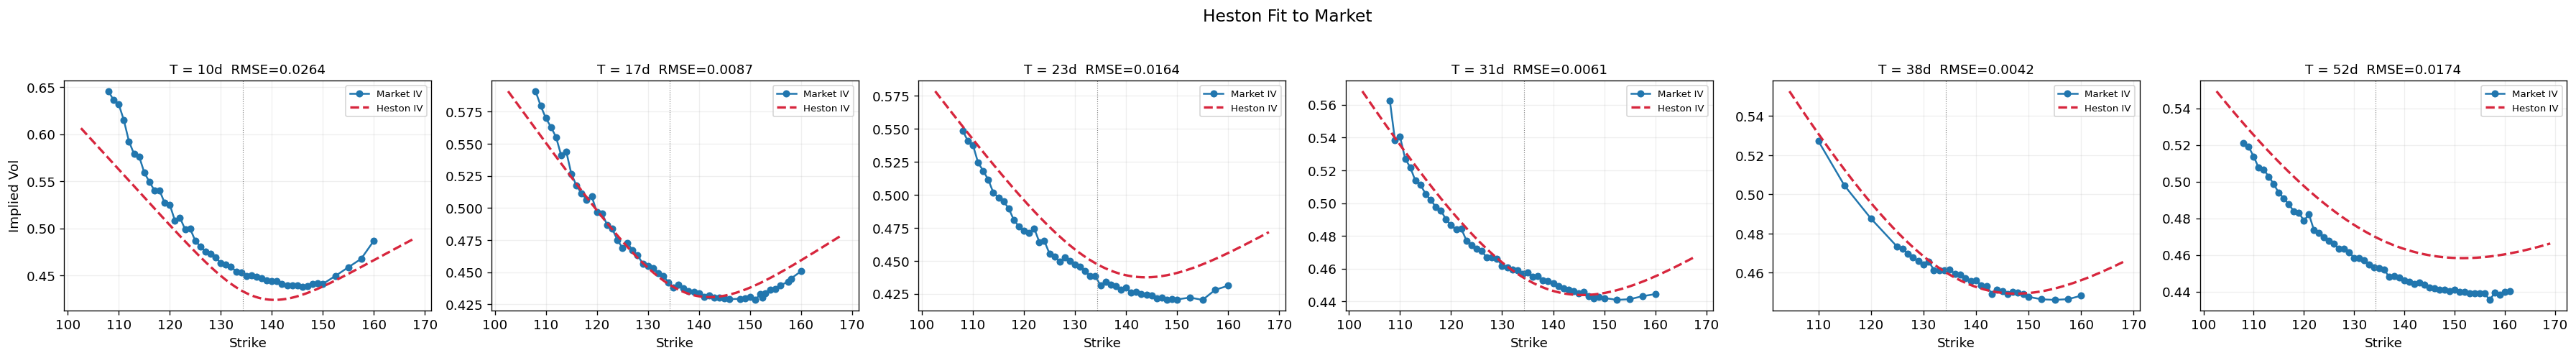


  Building Dupire local-vol surface from market IVs …


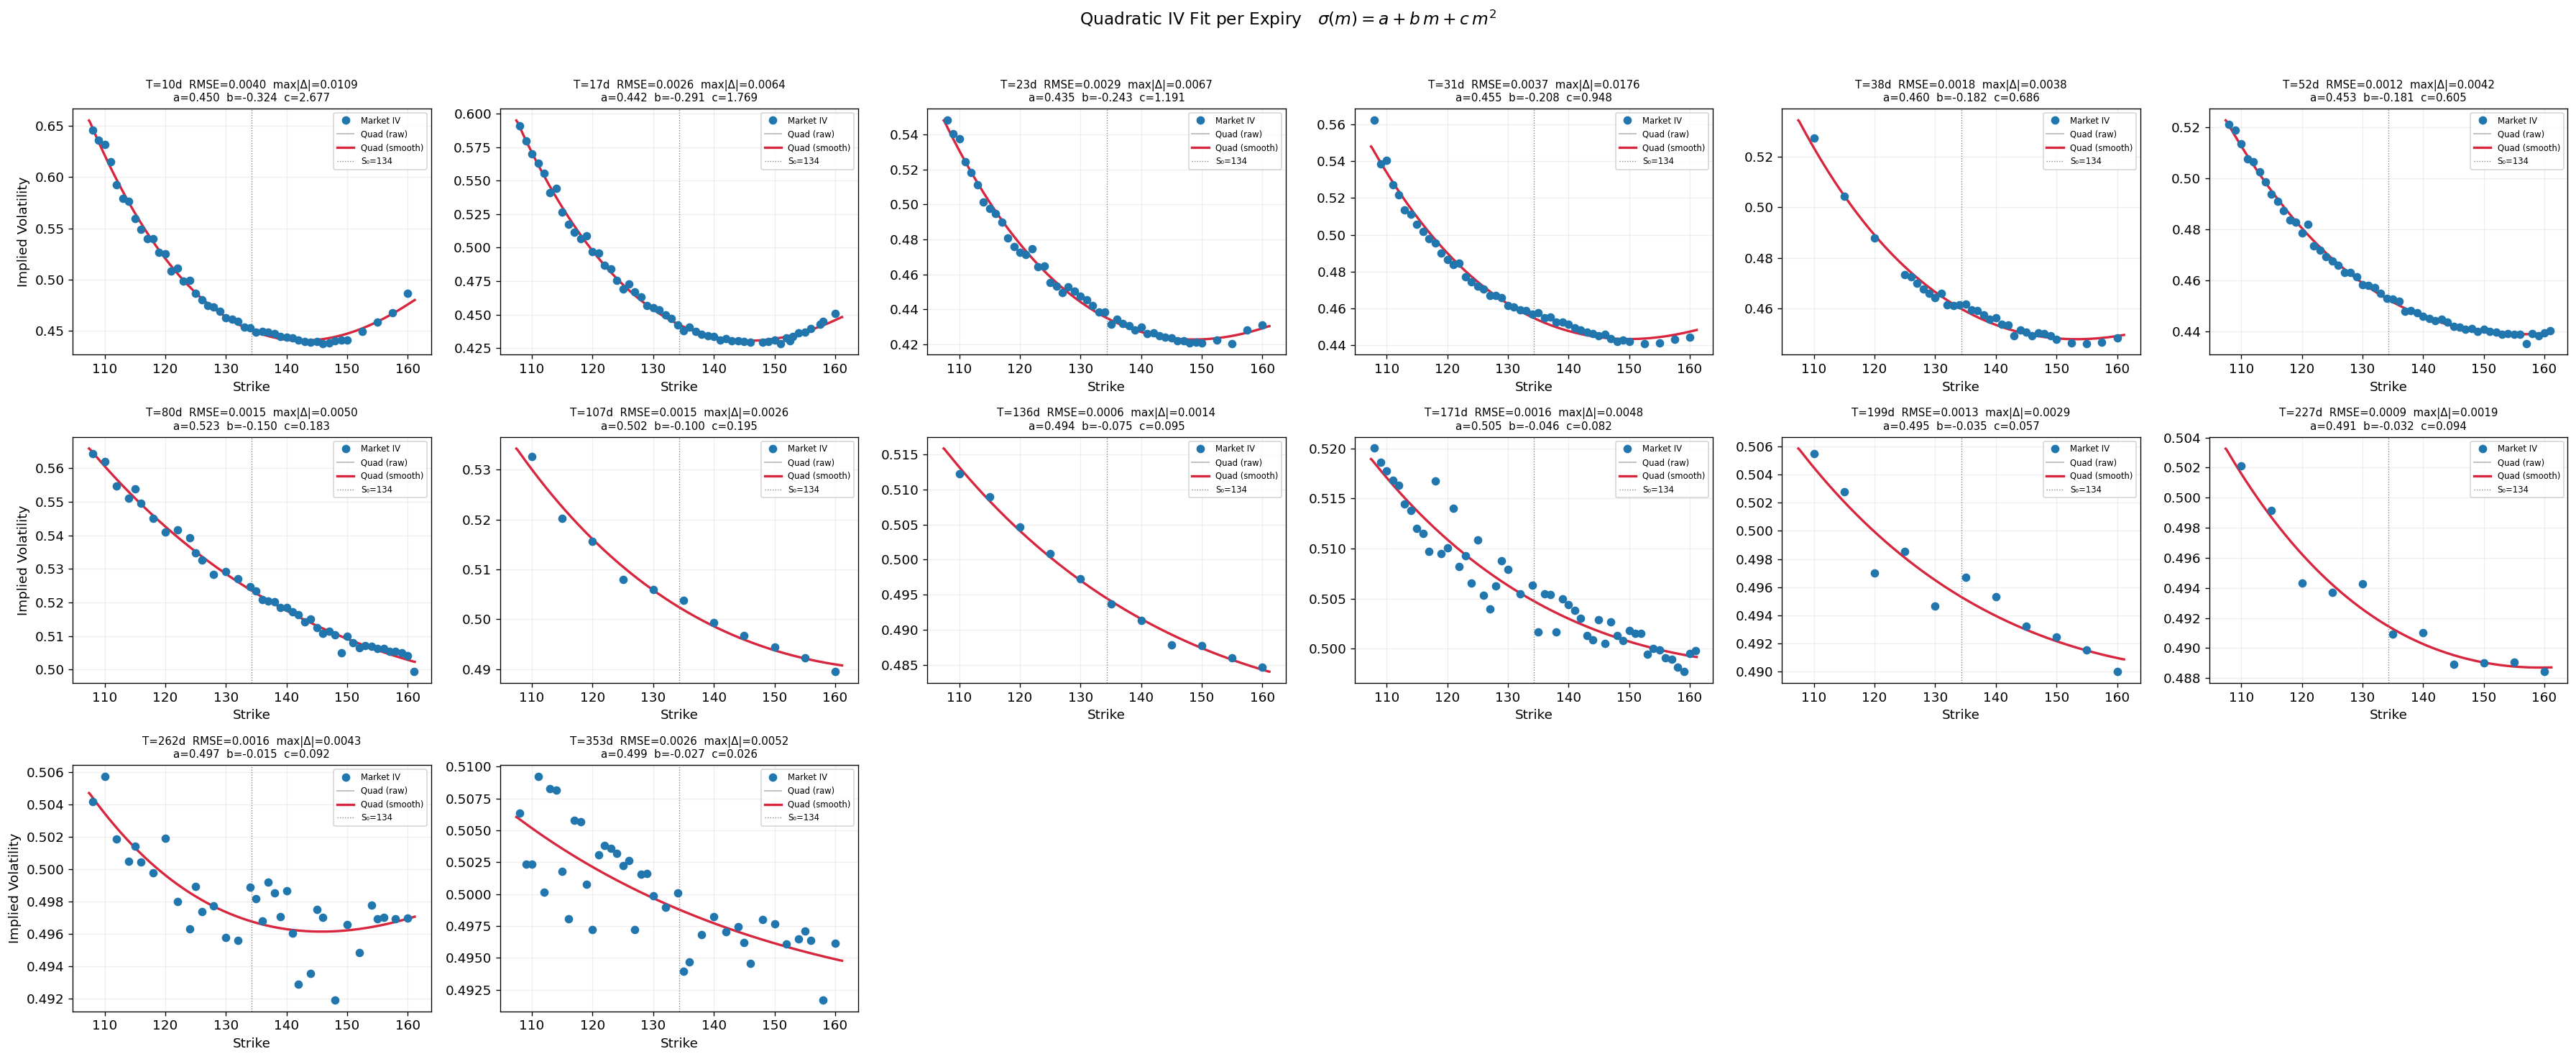

  Market local vol ∈ [0.0200, 1.0040]   (26.5% fell back to IV²)


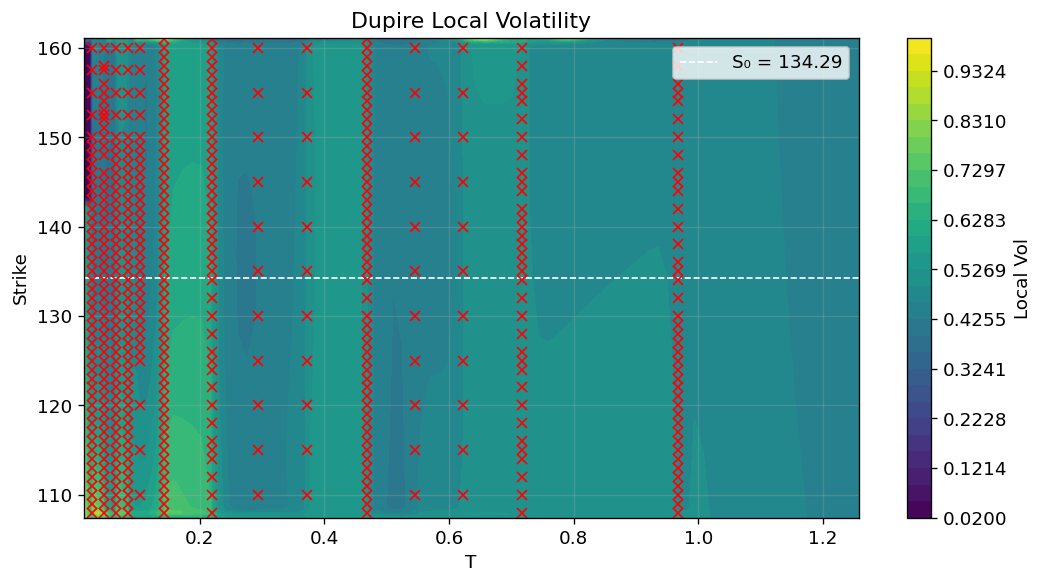


  Estimating SLV stochastic-vol parameters …
  Estimated SLV params:
        sigma0 = 0.3395
            Y0 = -1.2424
           rho = -0.6986
         gamma = 4.3127
         kappa = 13.6445
      kappa_bw = 1.0000
         N_cal = 50000

  SLV smile calibration check:
  T=10d  max|ΔIV|=0.1240  RMSE=0.0725  [14/47 strikes, ±5% mono, N=200k]  !
  T=17d  max|ΔIV|=0.0559  RMSE=0.0446  [14/52 strikes, ±5% mono, N=200k]  !
  T=23d  max|ΔIV|=0.0396  RMSE=0.0337  [14/47 strikes, ±5% mono, N=200k]  !
  T=31d  max|ΔIV|=0.0313  RMSE=0.0280  [13/47 strikes, ±5% mono, N=200k]  !
  T=38d  max|ΔIV|=0.0245  RMSE=0.0214  [13/33 strikes, ±5% mono, N=200k]  !
  T=52d  max|ΔIV|=0.0037  RMSE=0.0016  [13/54 strikes, ±5% mono, N=200k]  ✓
  T=80d  max|ΔIV|=0.0076  RMSE=0.0032  [22/43 strikes, ±10% mono, N=100k]  ✓
  T=107d  max|ΔIV|=0.0069  RMSE=0.0054  [5/11 strikes, ±10% mono, N=100k]  ✓
  T=136d  max|ΔIV|=0.0085  RMSE=0.0053  [11/11 strikes, ±100% mono, N=50k]  ✓
  T=171d  max|ΔIV|=0.0173  RMSE=0.0071  

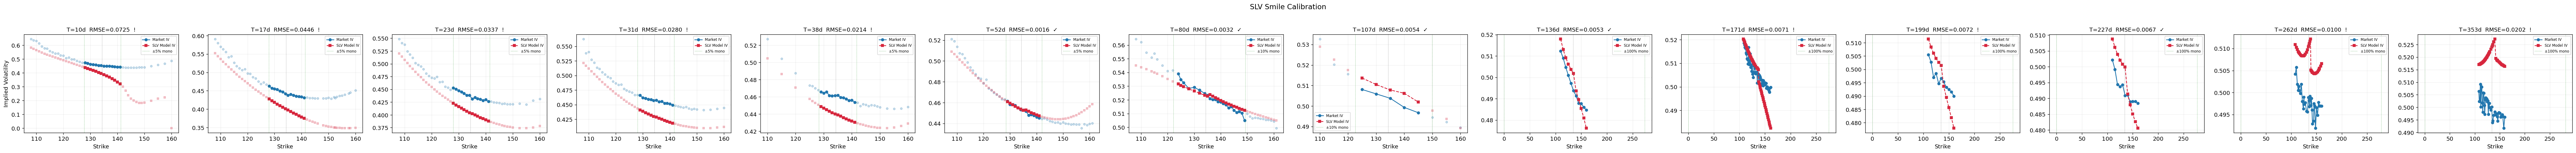

In [383]:
def fixed_slv_params(S0, expiries):
    """
    Fixed SLV parameters — sensible equity defaults.
    sigma0 anchored to ATM IV from shortest expiry.
    """
    # anchor sigma0 to short-end ATM IV
    exp0 = expiries[0]
    Ks  = np.array(exp0['strikes'])
    ivs = np.array(exp0['ivs'])
    order = np.argsort(Ks)
    sigma0 = float(np.interp(S0, Ks[order], ivs[order]))

    params = dict(
        sigma0   = sigma0,     # ATM IV (only thing from data)
        Y0       = 0.0,        # start at long-run mean
        rho      = -0.70,      # typical equity skew correlation
        gamma    = 0.50,       # moderate vol-of-vol
        kappa    = 2.0,        # moderate mean reversion
        kappa_bw = SLV_KAPPA_BW,
        N_cal    = SLV_N_CAL,
    )

    print(f"  Fixed SLV params (σ₀ from ATM IV = {sigma0:.4f}):")
    for k, val in params.items():
        print(f"    {k:>10s} = {val:.4f}" if isinstance(val, float)
              else f"    {k:>10s} = {val}")
    return params

#-----------------------------------------------------------------#

all_ticker_results = {}

for ticker in TICKERS:
    print(f"\n{'═'*70}")
    print(f"  {ticker}")
    print(f"{'═'*70}")

    # ── Load data ──
    stock_df, opt_df, zero_df = load_all_data(ticker)

    # ── Reference date & spot ──
    ref_date = opt_df['date'].max()
    S0 = float(stock_df.loc[stock_df['date'] == ref_date, 'close'].iloc[0])
    print(f"\n  Reference date: {ref_date.date()}   S₀ = {S0:.2f}")

    # ── Build expiry surface from WRDS ──
    S0_ref, expiries = build_expiries_from_wrds(opt_df, stock_df, zero_df, ref_date)

    # ── Calibrate Heston on reference date ──
    print("\n  Calibrating Heston …")
    r_fn = lambda d, dte: get_risk_free_rate(zero_df, d, dte)
    odf_ref = opt_df[opt_df['date'] == ref_date]
    heston_params = calibrate_heston_on_date(odf_ref, S0, r_fn, ref_date)

    v0, kappa_h, theta_h, xi_h, rho_h = heston_params
    print(f"  v0={v0:.4f}  κ={kappa_h:.2f}  θ={theta_h:.4f}  ξ={xi_h:.4f}  ρ={rho_h:.4f}")
    print(f"  Feller: 2κθ/ξ² = {2*kappa_h*theta_h/xi_h**2:.3f}")

    plot_calibration_fit(expiries, S0, heston_params)

    # # ── Build local-vol surface ──
    # print("\n  Building Dupire local-vol surface …")
    # vol_fn, T_grid, K_grid, lv_surface = build_heston_local_vol(S0, heston_params, expiries)
    # plot_local_vol_surface(T_grid, K_grid, lv_surface, S0, expiries)
    
    # ── Build local-vol surface directly from market IVs ──
    print("\n  Building Dupire local-vol surface from market IVs …")
    vol_fn, T_grid, K_grid, lv_surface = build_market_local_vol_quad(S0, expiries) # also try: build_market_local_vol_quad
    plot_local_vol_surface(T_grid, K_grid, lv_surface, S0, expiries)

    # ── Estimate SLV parameters ──
    print("\n  Estimating SLV stochastic-vol parameters …")
    slv_p = estimate_slv_params(stock_df)
    # slv_p = fixed_slv_params(S0, expiries)

    # ── SLV smile check ──
    print("\n  SLV smile calibration check:")
    plot_slv_smile_check(expiries, S0, slv_p, vol_fn)

    all_ticker_results[ticker] = { 
        'S0': S0, 'expiries': expiries,
        'heston_params': heston_params,
        'vol_fn': vol_fn, 'slv_params': slv_p,
        'T_grid': T_grid, 'K_grid': K_grid, 'lv_surface': lv_surface,
        'stock_df': stock_df, 'opt_df': opt_df, 'zero_df': zero_df,
    }

## 13. American Put Pricing (LSM + BA Bounds)

In [382]:
def get_nearest_strikes(opt_df, ref_date, S0, T_target, cp='P', n=5):
    """
    Return the n unique strikes closest to S0 for the expiry nearest T_target.
    """
    ref_date = pd.Timestamp(ref_date)
    df = opt_df[
        (opt_df['date'] == ref_date) &
        (opt_df['cp_flag'] == cp)
    ].copy()

    if df.empty:
        return [], None

    # closest expiry to T_target
    df['T_years'] = df['dte'] / 365.0
    df['T_diff']  = (df['T_years'] - T_target).abs()
    best_T_diff   = df['T_diff'].min()
    df = df[df['T_diff'] == best_T_diff]

    # deduplicate: keep one row per strike (highest volume or first)
    if 'volume' in df.columns:
        df = df.sort_values('volume', ascending=False)
    df = df.drop_duplicates(subset='strike', keep='first')

    # n closest to ATM
    df['K_diff'] = (df['strike'] - S0).abs()
    df = df.nsmallest(n, 'K_diff')
    df = df.sort_values('strike')

    strikes = df['strike'].tolist()

    # build a dict keyed by strike for quick lookup
    mkt_dict = {}
    for _, row in df.iterrows():
        K = float(row['strike'])
        mkt_dict[K] = {
            'mid':    float(row['mid']),
            'bid':    float(row['best_bid']),
            'ask':    float(row['best_offer']),
            'iv':     float(row['iv']),
            'strike': K,
            'exdate': row['exdate'],
            'dte':    int(row['dte']),
            'T':      float(row['T_years']),
        }

    return strikes, mkt_dict


# ──────────────────────────────────────────────────────────────

for ticker in TICKERS:
    res = all_ticker_results[ticker]
    S0        = res['S0']
    vol_fn    = res['vol_fn']
    slv_p     = res['slv_params']
    expiries  = res['expiries']
    zero_df   = res['zero_df']
    opt_df    = res['opt_df']
    ref_date  = opt_df['date'].max()

    exp_ref = min(expiries, key=lambda e: abs(e['T'] - T_PRICE))
    r_price = exp_ref['R']

    # ── Find 5 nearest-ATM strikes with actual market data ──
    K_puts, mkt_dict = get_nearest_strikes(
        opt_df, ref_date, S0, T_PRICE, cp='P', n=5)

    if not K_puts:
        print(f"\n  {ticker}: no market puts found near T={T_PRICE} — skipping")
        continue

    exercise_idx_p = np.round(np.linspace(0, N_STEPS_PRICE, N_EXERCISE + 1)).astype(int)
    ts_ex          = np.linspace(0, T_PRICE, N_EXERCISE + 1)
    dt_p           = T_PRICE / N_STEPS_PRICE

    # ── Calibrate leverage ──
    print(f"\n{'='*60}")
    print(f"  {ticker} — American Put Pricing   T={T_PRICE}   r={r_price:.4f}")
    print(f"  Ref date: {ref_date.date()}   S₀ = {S0:.2f}")
    print(f"  Strikes (5 nearest ATM): {K_puts}")
    print(f"{'='*60}")
    print("  Calibrating SLV leverage …")
    t0 = time.time()
    lev_store_p, _, _ = particle_method(
        S0, slv_p['sigma0'], slv_p['Y0'], slv_p['rho'],
        slv_p['gamma'], slv_p['kappa'],
        T_PRICE, N_STEPS_PRICE, slv_p['N_cal'], vol_fn, slv_p['kappa_bw'])
    print(f"  Done ({time.time()-t0:.1f}s)")

    # ── Training paths ──
    paths_train, Y_train = slv_paths_matrix(
        S0, slv_p['sigma0'], slv_p['Y0'], slv_p['rho'],
        slv_p['gamma'], slv_p['kappa'],
        T_PRICE, N_STEPS_PRICE, slv_p['N_cal'], lev_store_p,
        exercise_idx_p, seed=42)

    # ── Print market prices header ──
    print(f"\n  {'─'*78}")
    print(f"  Market Puts from WRDS  (ref: {ref_date.date()}, "
          f"expiry closest to T={T_PRICE}y)")
    print(f"  {'─'*78}")
    print(f"  {'K':>10s}  {'Bid':>8s}  {'Ask':>8s}  {'Mid':>8s}  "
          f"{'IV':>7s}  {'DTE':>5s}  {'Exdate':>12s}  {'Mny':>7s}")
    for K_put in K_puts:
        m = mkt_dict[K_put]
        mny = K_put / S0
        print(f"  {m['strike']:>10.1f}  {m['bid']:>8.2f}  {m['ask']:>8.2f}  "
              f"{m['mid']:>8.2f}  {m['iv']:>7.4f}  {m['dte']:>5d}  "
              f"{m['exdate'].strftime('%Y-%m-%d'):>12s}  {mny:>7.3f}")
    print()

    # ── BA paths (generate once, reuse for all strikes) ──
    paths_ba, Y_ba = slv_paths_matrix(
        S0, slv_p['sigma0'], slv_p['Y0'], slv_p['rho'],
        slv_p['gamma'], slv_p['kappa'],
        T_PRICE, N_STEPS_PRICE, N_BA_PATHS, lev_store_p,
        exercise_idx_p, seed=777)

    # ── Price each strike ──
    for K_put in K_puts:
        mkt   = mkt_dict[K_put]
        mkt_mid = mkt['mid']
        mny     = K_put / S0

        print(f"\n  ── K = {K_put:.1f}  (moneyness {mny:.3f}) {'─'*40}")

        # ── Poly-3 ──
        t0 = time.time()
        price_poly, pol_poly, diag_poly = ls_pricer_diag(
            paths_train, K_put, r_price, ts_ex, regression_polynomial, degree=3)
        t_poly = time.time() - t0

        # ── BA upper bound ──
        print("    Computing BA upper bound …", end="", flush=True)
        t0 = time.time()
        upper_poly = compute_ba_upper(
            price_poly, pol_poly['models'], paths_ba, Y_ba,
            lev_store_p, exercise_idx_p,
            slv_p['sigma0'], slv_p['rho'], slv_p['gamma'], slv_p['kappa'],
            r_price, ts_ex, N_NESTED, K_put, dt_p)
        t_ba = time.time() - t0
        print(f" done ({t_ba:.1f}s)")

        avg_r2_poly = np.mean([d['r2'] for d in diag_poly])

        diff = price_poly - mkt_mid
        gap  = upper_poly - price_poly

        # ── Results ──
        print(f"\n    {'Method':<8s}  {'LSM':>8s}  {'BA Up':>8s}  {'Gap':>7s}  "
              f"{'Market':>8s}  {'LSM-Mkt':>8s}  {'AvgR²':>7s}  {'Time':>6s}")
        print(f"    {'─'*72}")
        print(f"    {'Poly-3':<8s}  {price_poly:>8.4f}  {upper_poly:>8.4f}  "
              f"{gap:>7.4f}  {mkt_mid:>8.2f}  {diff:>+8.4f}  "
              f"{avg_r2_poly:>7.4f}  {t_poly:>5.1f}s")

        in_bounds = price_poly <= mkt_mid <= upper_poly
        pct_err   = 100 * abs(diff) / mkt_mid if mkt_mid > 0 else np.nan
        print(f"    Market in [LSM, BA]? {'✓ YES' if in_bounds else '✗ NO'}   "
              f"|err| = {pct_err:.1f}%")
        if mkt_mid < price_poly:
            print(f"    ⚠ Market < LSM lower bound (model overprices)")
        elif mkt_mid > upper_poly:
            print(f"    ⚠ Market > BA upper bound (model underprices)")


  NVDA — American Put Pricing   T=0.6219178082191781   r=0.0485
  Ref date: 2024-12-31   S₀ = 134.29
  Strikes (5 nearest ATM): [125.0, 130.0, 135.0, 140.0, 145.0]
  Calibrating SLV leverage …
  Done (4.9s)

  ──────────────────────────────────────────────────────────────────────────────
  Market Puts from WRDS  (ref: 2024-12-31, expiry closest to T=0.6219178082191781y)
  ──────────────────────────────────────────────────────────────────────────────
           K       Bid       Ask       Mid       IV    DTE        Exdate      Mny
       125.0     13.95     14.10     14.02   0.4903    227    2025-08-15    0.931
       130.0     16.35     16.50     16.43   0.4891    227    2025-08-15    0.968
       135.0     18.95     19.10     19.02   0.4878    227    2025-08-15    1.005
       140.0     21.75     21.90     21.82   0.4867    227    2025-08-15    1.043
       145.0     24.75     24.90     24.82   0.4860    227    2025-08-15    1.080


  ── K = 125.0  (moneyness 0.931) ─────────────────